# Intro

In [1]:
%env CUDA_VISIBLE_DEVICES=1

env: CUDA_VISIBLE_DEVICES=1


In [2]:
DATA_DIR = '/home/HDD6TB/datasets/emotions/ABAW/ABAW_11/BAH-data/'
VIDEO_DIR=DATA_DIR+'Videos/'
#AUDIO_DIR=DATA_DIR+'audios/Videos/'
FACES_DIR=DATA_DIR+'cropped-aligned-faces/Videos/'
TRANSCRIPTION_DIR=DATA_DIR+'transcription/Videos/'

TRAIN_LABELS=DATA_DIR+'split/train.txt'
VAL_LABELS=DATA_DIR+'split/val.txt'
TEST_LABELS=DATA_DIR+'split/test.txt'          # public test (525 videos, with labels)
ANNOTATION_FRAME_LABELS=DATA_DIR+'video_annotation_transcript.yaml'

FRAME_TRAIN=DATA_DIR+'split-frames/train.txt'
FRAME_VAL=DATA_DIR+'split-frames/val.txt'
FRAME_TEST=DATA_DIR+'split-frames/test.txt'

TEST_DATA_DIR = '/home/HDD6TB/datasets/emotions/ABAW/ABAW_11/BAH-data/test_data/' # Private test

PRIVATE_TEST_LIST = TEST_DATA_DIR + 'split/test.txt'
PRIVATE_ANNOTATION = TEST_DATA_DIR + 'video_annotation_transcript.yaml'
PRIVATE_VIDEO_DIR = TEST_DATA_DIR + 'Videos/'
#PRIVATE_AUDIO_DIR = TEST_DATA_DIR + 'audios/Videos/'
PRIVATE_FACES_DIR = TEST_DATA_DIR + 'cropped-aligned-faces/Videos/'


In [3]:
import os
import cv2
import pathlib
import glob
import random
import numpy as np
import time
import pickle
import pandas as pd
import csv  
import matplotlib.pyplot as plt
import yaml
import zipfile
import wave, struct

from fnmatch       import fnmatch
from PIL           import Image
from collections   import defaultdict
from itertools     import chain
from tqdm          import tqdm
from tqdm.notebook import tqdm
from scipy.interpolate import interp1d

from sklearn.model_selection import train_test_split
from sklearn.ensemble        import RandomForestClassifier,RandomForestRegressor
from sklearn                 import svm, metrics, preprocessing
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.decomposition   import PCA
from sklearn.pipeline        import Pipeline
from sklearn.metrics         import (confusion_matrix, precision_score, recall_score, accuracy_score, f1_score, 
roc_auc_score, average_precision_score, classification_report)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torchvision import datasets, transforms
from transformers import Wav2Vec2Processor, Wav2Vec2Model,AutoProcessor, HubertModel
import torchaudio

2026-07-10 18:54:05.729087: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-10 18:54:06.052016: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-10 18:54:06.052094: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-10 18:54:06.052807: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-10 18:54:06.163058: I tensorflow/core/platform/cpu_feature_g

In [4]:
print(f"Torch: {torch.__version__}")
device = 'cuda'
use_cuda = torch.cuda.is_available()
print(use_cuda)

Torch: 2.7.1+cu118
True


# Extract features

## Faces

### Model

In [52]:
if True:
    if False:
        model_name='mbf_va_mtl.pt'

        IMG_SIZE=112

        test_transforms = transforms.Compose(
        [
            transforms.Resize((112,112)),
            #transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5],std=[0.5, 0.5, 0.5])
        ]
        )

        import sys
        sys.path.append("/home/avsavchenko/src/distr/insightface/recognition/arcface_torch/backbones/")
        import mobilefacenet
    else:
        if False:
            #model_name='affectnet_vggface2_enet2_gmp_smooth.pt'
            model_name='enet_b2_8_best.pt'
            #model_name='enet_b2_7.pt'
            IMG_SIZE=260 #224 #
        else:
            #model_name='affectnet_vggface2_enet0.pt'
            #model_name='affectnet_vggface2_enet0_new.pt'
            #model_name='enet_b0_7.pt'
            #model_name='enet_b0_8_best_afew.pt'
            #model_name='enet_b0_8_best_vgaf.pt'
            model_name='enet_b0_8_va_mtl.pt'
            #model_name='mobilevit_va_mtl.pt'

            IMG_SIZE=224

        #IMG_SIZE=112

        test_transforms = transforms.Compose(
            [
                transforms.Resize((IMG_SIZE,IMG_SIZE)),
                #transforms.RandomHorizontalFlip(),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                             std=[0.229, 0.224, 0.225])
            ]
        )
        np_transforms = transforms.Compose(
            [
                transforms.ToPILImage(None),
                transforms.Resize((IMG_SIZE,IMG_SIZE)),
                #transforms.RandomHorizontalFlip(),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                             std=[0.229, 0.224, 0.225])
            ]
        )


    print(model_name)
    feature_extractor_model = torch.load('/home/avsavchenko/src/face-emotion-recognition/models/affectnet_emotions/'+model_name,weights_only=False)

else:
    IMG_SIZE=112
    
    test_transforms = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])])  
    
    import sys
    DDAMNFN_PATH='/home/avsavchenko/src/distr/DDAMFN'
    sys.path.append(DDAMNFN_PATH)
    from networks.DDAM import DDAMNet

    if False:
        feature_extractor_model = DDAMNet(num_class=8, num_head=2)
        model_name='affectnet8_epoch4_acc0.6462'
    else:
        feature_extractor_model = DDAMNet(num_class=10, num_head=2)
        model_name='affectnet8_epoch9_acc0.642_mtl_2'
    feature_extractor_model.load_state_dict(torch.load(DDAMNFN_PATH+'/checkpoints/'+model_name+'.pth')['model_state_dict'])
    feature_extractor_model.bn=torch.nn.Identity()
    print(model_name)

enet_b0_8_va_mtl.pt


In [53]:
feature_extractor_model

EfficientNet(
  (conv_stem): Conv2dSame(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
  (bn1): BatchNormAct2d(
    32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (bn1): BatchNormAct2d(
          32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2): BatchNormAct2d(
          16, eps=

In [54]:
if False:
    classifier_weights=feature_extractor_model.classifier[0].weight.cpu().data.numpy()
    classifier_bias=feature_extractor_model.classifier[0].bias.cpu().data.numpy()
elif True:
    classifier_weights=feature_extractor_model.classifier.weight.cpu().data.numpy()
    classifier_bias=feature_extractor_model.classifier.bias.cpu().data.numpy()
elif False:
    classifier_weights=feature_extractor_model.head.fc.weight.cpu().data.numpy()
    classifier_bias=feature_extractor_model.head.fc.bias.cpu().data.numpy()
else:
    classifier_weights=feature_extractor_model.fc.weight.cpu().data.numpy()
    classifier_bias=feature_extractor_model.fc.bias.cpu().data.numpy()
print(classifier_weights.shape,classifier_weights)
print(classifier_bias.shape,classifier_bias)

(10, 1280) [[ 0.00679121  0.09001139  0.0694934  ...  0.10351563 -0.00995514
  -0.17376047]
 [-0.004085   -0.07134113 -0.12164655 ... -0.05029012  0.03059323
   0.08198261]
 [-0.0034241  -0.06510569 -0.00448079 ...  0.04248156 -0.10535879
  -0.00544419]
 ...
 [ 0.07878461 -0.03540913 -0.06665969 ... -0.10314589  0.1332206
  -0.06119434]
 [-0.02409821 -0.00270485  0.00887998 ... -0.00501176  0.01345664
  -0.02131553]
 [-0.04529824 -0.04590099 -0.00950194 ...  0.00753843  0.02128105
  -0.05743075]]
(10,) [-0.03629377 -0.00268708 -0.05411524  0.01482256  0.13788255  0.09921926
 -0.05259513 -0.0124341   0.0816549   0.04621203]


In [55]:
if True:
    feature_extractor_model.classifier=torch.nn.Identity()
elif False:
    feature_extractor_model.head.fc=torch.nn.Identity()
else:
    feature_extractor_model.fc=torch.nn.Identity()
feature_extractor_model=feature_extractor_model.to(device)
feature_extractor_model.eval()

EfficientNet(
  (conv_stem): Conv2dSame(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
  (bn1): BatchNormAct2d(
    32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (bn1): BatchNormAct2d(
          32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2): BatchNormAct2d(
          16, eps=

In [56]:
# get logits

def get_probab(features):
    x=np.dot(features,np.transpose(classifier_weights))+classifier_bias
    return x

### Extract features from faces

In [ ]:
# train

print(test_transforms)
data_dir=FACES_DIR
print(data_dir)

videoname2features,videoname2scores,videoname2img_names={},{},{}
for subject in tqdm(sorted(os.listdir(data_dir))):
    subject_dir=os.path.join(data_dir,subject)   
    for visit_name in sorted(os.listdir(subject_dir)):
        visit_dir=os.path.join(subject_dir,visit_name)   
        for question_name in sorted(os.listdir(visit_dir)):
            question_dir=os.path.join(visit_dir,question_name)   
            
            videoname='Videos/'+subject+'/'+visit_name+'/'+question_name # добавил 'Videos/'+
            #print(videoname)

            X_features,img_names=[],[]
            imgs=[]
            for img_name in sorted(os.listdir(question_dir), key=compare_filenames):#[::5]:
                #print(video_dir,img_name)
                img = Image.open(os.path.join(question_dir,img_name))
                img_tensor = test_transforms(img)
                if img.size:
                    img_names.append(videoname+'/'+img_name)
                    imgs.append(img_tensor)
                    if len(imgs)>=64: #48: #96: #32:        
                        #features,_,_ = feature_extractor_model(torch.stack(imgs, dim=0).to(device))
                        features = feature_extractor_model(torch.stack(imgs, dim=0).to(device))
                        features=features.data.cpu().numpy()
                        #print(features.shape)

                        if len(X_features)==0:
                            X_features=features
                        else:
                            X_features=np.concatenate((X_features,features),axis=0)
                        imgs=[]

            if len(imgs)>0:        
                #features,_,_ = feature_extractor_model(torch.stack(imgs, dim=0).to(device))
                features = feature_extractor_model(torch.stack(imgs, dim=0).to(device))
                features=features.data.cpu().numpy()

                if len(X_features)==0:
                    X_features=features
                else:
                    X_features=np.concatenate((X_features,features),axis=0)

                imgs=[]
            if len(X_features)>0:
                X_scores=get_probab(X_features)
                #print(X_features.shape,X_scores.shape)
                videoname2features[videoname]=X_features
                videoname2scores[videoname]=X_scores
                videoname2img_names[videoname]=img_names

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
/home/HDD6TB/datasets/emotions/ABAW/ABAW_11/BAH-data/cropped-aligned-faces/Videos/


  0%|          | 0/300 [00:00<?, ?it/s]

In [62]:
print(len(videoname2img_names))

1427


### Save/load features 

In [5]:
if False:
    #model_name='enet_b2_8_best'
    #model_name='enet_b0_8_best_vgaf'
    #model_name='ddamfnet_8'
    has_va=False
else:
    model_name='enet_b0_8_va_mtl'
    #model_name='mobilevit_va_mtl'
    #model_name='mbf_va' - было ранее
    #model_name='ddamfnet_mtl'
    has_va=True
    
MODEL2FEATURES='bah_'+model_name+'_aligned.pickle' 
#MODEL2FEATURES='bah_ddamfnet_mtl_aligned.pickle'
#MODEL2FEATURES='bah_mbf_va_aligned.pickle'
#MODEL2FEATURES='bah_mobilevit_va_mtl_aligned.pickle'

print(MODEL2FEATURES)

bah_enet_b0_8_va_mtl_aligned.pickle


In [6]:
if False:
    with open(MODEL2FEATURES, 'wb') as handle:
        pickle.dump([videoname2features,videoname2scores,videoname2img_names], handle, protocol=pickle.HIGHEST_PROTOCOL)
else:
    with open(MODEL2FEATURES, 'rb') as handle:
        videoname2features,videoname2scores,videoname2img_names=pickle.load(handle)

In [12]:
test_video_name='Videos/82734/Visite_1/82734_Question_5_2024-11-20_16-15-41_Video.mp4'
print(len(videoname2features),videoname2features[test_video_name].shape,videoname2scores[test_video_name].shape)

1427 (928, 1280) (928, 10)


## Audio

### Extract wave from video

In [27]:
# train
import subprocess
AUDIO_DIR='audios/Videos/'

for subject in tqdm(sorted(os.listdir(VIDEO_DIR))):
    subject_dir=os.path.join(VIDEO_DIR,subject)   
    for visit_name in sorted(os.listdir(subject_dir)):
        visit_dir=os.path.join(subject_dir,visit_name)   
        audio_dir=AUDIO_DIR+subject+'/'+visit_name+'/'
        if not os.path.exists(audio_dir):
            os.makedirs(audio_dir)
        for question_name in sorted(os.listdir(visit_dir)):
            video_path=os.path.join(visit_dir,question_name)   
            waveFile=audio_dir+question_name+'.wav'
            #command = "ffmpeg -i '"+video_path+"' -ac 1 -ar 16000 -vn '"+waveFile+"'"
            #print(command)
            #os.system(command)
            subprocess.run(
                [
                    'ffmpeg', '-hide_banner', '-loglevel', 'error', '-nostats',
                    '-i', video_path,
                    '-ac', '1', '-ar', '16000', '-vn',
                    waveFile,
                ],
                stdout=subprocess.DEVNULL,
                stderr=subprocess.DEVNULL,
            )

  0%|          | 0/300 [00:00<?, ?it/s]

### Model

In [69]:
if False:
    processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")
    model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base-960h")
else:
    processor = AutoProcessor.from_pretrained("facebook/hubert-large-ls960-ft")
    model = HubertModel.from_pretrained("facebook/hubert-large-ls960-ft")
model.eval()

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

HubertModel(
  (feature_extractor): HubertFeatureEncoder(
    (conv_layers): ModuleList(
      (0): HubertLayerNormConvLayer(
        (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,))
        (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (activation): GELUActivation()
      )
      (1-4): 4 x HubertLayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,))
        (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (activation): GELUActivation()
      )
      (5-6): 2 x HubertLayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,))
        (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (activation): GELUActivation()
      )
    )
  )
  (feature_projection): HubertFeatureProjection(
    (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (projection): Linear(in_features=512, out_features=1024, bias=True)
    (dropout): Dropout(p=

### Extract features from audio

In [29]:
#train

videoname2audio_features={}
for subject in tqdm(sorted(os.listdir(VIDEO_DIR))):
    subject_dir=os.path.join(VIDEO_DIR,subject)   
    for visit_name in sorted(os.listdir(subject_dir)):
        visit_dir=os.path.join(subject_dir,visit_name)
        audio_dir=AUDIO_DIR+subject+'/'+visit_name+'/'
        for question_name in sorted(os.listdir(visit_dir)):
            videoname='Videos/'+subject+'/'+visit_name+'/'+question_name # Добавил Vidoes/
            waveFile=audio_dir+question_name+'.wav'
            array, fs = torchaudio.load(waveFile)
            inp = processor(array.squeeze(), sampling_rate=fs, return_tensors="pt")
            with torch.no_grad():
                outputs = model(**inp)
            videoname2audio_features[videoname]=outputs.last_hidden_state.numpy()[0]
    #print(videoname2audio_features[videoname].shape)

  0%|          | 0/300 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

### Save/load

In [85]:
#MODEL2AUDIOFEATURES='bah_wav2vec2.pickle'
MODEL2AUDIOFEATURES='bah_hubert.pickle'

if False:
    with open(MODEL2AUDIOFEATURES, 'wb') as handle:
        pickle.dump(videoname2audio_features, handle, protocol=pickle.HIGHEST_PROTOCOL)
else:
    with open(MODEL2AUDIOFEATURES, 'rb') as handle:
        videoname2audio_features=pickle.load(handle)

In [43]:
test_video_name='Videos/82734/Visite_1/82734_Question_5_2024-11-20_16-15-41_Video.mp4'
print(len(videoname2audio_features), videoname2audio_features[test_video_name].shape)

1427 (1932, 1024)


### Interp

In [17]:
videoname2audio_features_sampled={}
for videoname in videoname2img_names:
    audio_embs=videoname2audio_features[videoname]
    x = np.linspace(0, 1, audio_embs.shape[0])
    f = interp1d(x, audio_embs,axis=0)
    new_x=np.linspace(0, 1, len(videoname2img_names[videoname]))
    videoname2audio_features_sampled[videoname]=f(new_x)

In [7]:
MODEL2AUDIOFEATURES='interp_bah_hubert.pickle'

if False:
    with open(MODEL2AUDIOFEATURES, 'wb') as handle:
        pickle.dump(videoname2audio_features_sampled, handle, protocol=pickle.HIGHEST_PROTOCOL)
else:
    with open(MODEL2AUDIOFEATURES, 'rb') as handle:
        videoname2audio_features_sampled=pickle.load(handle)

In [26]:
print(len(videoname2audio_features_sampled), videoname2audio_features_sampled[test_video_name].shape)

1427 (928, 1024)


## Text 

### Read transcript

In [ ]:
with open(ANNOTATION_FRAME_LABELS, encoding='utf-8') as f:
    content = yaml.load(f, Loader=yaml.UnsafeLoader)
videoname2text = {}
for videoname, entry in content.items():
    videoname2text[videoname] = entry['transcript']['text']

In [22]:
AUDIO2TEXTS='bah_text.pickle'

if False:
    with open(AUDIO2TEXTS, 'wb') as handle:
        pickle.dump(videoname2text, handle, protocol=pickle.HIGHEST_PROTOCOL)
else:
    with open(AUDIO2TEXTS, 'rb') as handle:
        videoname2text=pickle.load(handle)

In [23]:
test_video_name='Videos/82734/Visite_1/82734_Question_5_2024-11-20_16-15-41_Video.mp4'
print(len(videoname2text),videoname2text[test_video_name])

1427  I am pretty much always willing to go out with friends for dinner. If I get invited out for a meal at either a new restaurant or one that we go to regularly, I'm pretty much always willing to go. It's a lot of fun. It doesn't really matter if I had a long or hard day at work. It's nice to get out and spend time with my friends. So it's very rare that I would not go unless I was like really sick and couldn't make it but otherwise I always want to go out and try new food and spend time with my friends and family trying out different restaurants in the city.


### Feature extraction 

In [ ]:
# Вариант 1.

In [76]:
from transformers import pipeline
model_path="SamLowe/roberta-base-go_emotions"
classifier = pipeline(task="feature-extraction", model=model_path, tokenizer=model_path, max_length=512, truncation=True)

Some weights of RobertaModel were not initialized from the model checkpoint at SamLowe/roberta-base-go_emotions and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use cuda:0


In [25]:
text_embeddings_list=[]
sentences=[]
for videoname in tqdm(videoname2text):
    sentences.append(videoname2text[videoname])
    if len(sentences)>32:
        outputs=classifier(sentences, return_tensors="pt")
        for output in outputs:
            text_embeddings_list.append(output[0].numpy())
        sentences=[]
        #break
if len(sentences)>0:
    outputs=classifier(sentences, return_tensors="pt")
    for output in outputs:
        text_embeddings_list.append(output[0].numpy())
    sentences=[]

  0%|          | 0/1427 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [ ]:
# Вариант 2.

In [40]:
from sentence_transformers import SentenceTransformer
#model_name='distilroberta-base'
model_name='all-MiniLM-L6-v1'
#model_name='intfloat/e5-base-v2'
model_st = SentenceTransformer(model_name)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [41]:
text_embeddings_list=[]
sentences=[]
for videoname in tqdm(videoname2text):
    sentences.append(videoname2text[videoname])
    if len(sentences)>32:
        outputs=model_st.encode(sentences)
        for output in outputs:
            text_embeddings_list.append(output)
        sentences=[]
        #break
if len(sentences)>0:
    outputs=model_st.encode(sentences)
    for output in outputs:
        text_embeddings_list.append(output)
    sentences=[]
#print(text_embeddings_list[0].shape,text_embeddings_list[1].shape)

  0%|          | 0/1427 [00:00<?, ?it/s]

In [26]:
#text_embeddings_list[2].shape
text_embeddings={}
for i,videoname in enumerate(videoname2text):
    text_embeddings[videoname]=text_embeddings_list[i]

In [27]:
print(len(text_embeddings),text_embeddings[test_video_name].shape)

1427 (131, 768)


### Save/load

In [45]:
AUDIO2TEXT_EMBEDDINGS='bah_text_roberta-base-go_emotions.pickle'
#AUDIO2TEXT_EMBEDDINGS='bah_text_openai_small.pickle'
#AUDIO2TEXT_EMBEDDINGS='bah_text_gigachat.pickle'

if False:
    with open(AUDIO2TEXT_EMBEDDINGS, 'wb') as handle:
        pickle.dump(text_embeddings, handle, protocol=pickle.HIGHEST_PROTOCOL)
else:
    with open(AUDIO2TEXT_EMBEDDINGS, 'rb') as handle:
        text_embeddings=pickle.load(handle)

In [13]:
print(len(text_embeddings),text_embeddings[test_video_name].shape)

1427 (131, 768)


### Interp

In [73]:
videoname2text_features_sampled={}
for videoname in videoname2img_names:
    text_embs=text_embeddings[videoname]
    x = np.linspace(0, 1, text_embs.shape[0])
    f = interp1d(x, text_embs,axis=0)
    new_x=np.linspace(0, 1, len(videoname2img_names[videoname]))
    videoname2text_features_sampled[videoname]=f(new_x)
    #  print(len(videoname2img_names[videoname]),videoname2text_features_sampled[videoname].shape)

In [8]:
AUDIO2TEXT_EMBEDDINGS='interp_bah_text_roberta-base-go_emotions.pickle'
#AUDIO2TEXT_EMBEDDINGS='bah_text_openai_small.pickle'
#AUDIO2TEXT_EMBEDDINGS='bah_text_gigachat.pickle'

if False:
    with open(AUDIO2TEXT_EMBEDDINGS, 'wb') as handle:
        pickle.dump(videoname2text_features_sampled, handle, protocol=pickle.HIGHEST_PROTOCOL)
else:
    with open(AUDIO2TEXT_EMBEDDINGS, 'rb') as handle:
        videoname2text_features_sampled=pickle.load(handle)

In [28]:
print(len(videoname2text_features_sampled),videoname2text_features_sampled[test_video_name].shape)

1427 (928, 768)


----------

# Preprocess data

In [60]:
test_video_name='Videos/82734/Visite_1/82734_Question_5_2024-11-20_16-15-41_Video.mp4'
print(len(videoname2features))
print(f'{videoname2features[test_video_name].shape} - features from faces') #features from faces
print(f'{videoname2scores[test_video_name].shape} - scores from faces') #scores from faces
print(f'{videoname2audio_features[test_video_name].shape} - features from audios') #features from audios
print(f'{videoname2audio_features_sampled[test_video_name].shape} - interp features from audios') #interp features from audios
print(f'{text_embeddings[test_video_name].shape} - features from text') #features from text
print(f'{videoname2text_features_sampled[test_video_name].shape} - interp features from text') #interp features from audios

1427
(928, 1280) - features from faces
(928, 10) - scores from faces
(1932, 1024) - features from audios
(928, 1024) - interp features from audios
(131, 768) - features from text
(131, 768) - interp features from text


In [34]:
import pandas as pd
rows = []
for videoname in videoname2img_names:
    n_frames = videoname2features[videoname].shape[0]
    n_text = text_embeddings[videoname].shape[0]
    n_audio = videoname2audio_features[videoname].shape[0]
    interp_n_text = videoname2text_features_sampled[videoname].shape[0]
    interp_n_audio = videoname2audio_features_sampled[videoname].shape[0]
    
    rows.append({
        'n_frames': n_frames,
        'n_text': n_text,
        'n_audio': n_audio,
        'interp_n_text': interp_n_text,
        'interp_n_audio': interp_n_audio,
        'frames/text': n_frames / n_text,
        'audio/frames': n_audio / n_frames,
    })
df = pd.DataFrame(rows)
df.agg(['mean', 'std']).round(2)

,n_frames,n_text,n_audio,interp_n_text,interp_n_audio,frames/text,audio/frames
mean,642.34,70.83,1335.97,642.34,642.34,9.98,2.08
std,395.26,47.57,823.81,395.26,395.26,4.24,0.04


In [9]:
# Чтение ANNOTATION_FRAME_LABELS
# with open(ANNOTATION_FRAME_LABELS, 'r') as f:
#     content = yaml.safe_load(f)

# content загружается в секции Extract features/Text
if 'content' not in globals():
    with open(ANNOTATION_FRAME_LABELS, encoding='utf-8') as f:
        content = yaml.load(f, Loader=yaml.UnsafeLoader)

In [22]:
content[test_video_name].keys(),len(content)

(dict_keys(['all_cues', 'annotator_id', 'certainty_ah', 'fr_detailed_ah', 'frame_annotation', 'global_ah', 'time_detailed_ah', 'transcript']),
 1427)

In [10]:
def get_videonames(split_file):
    videoname2AH = {}
    with open(split_file, encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            video_path, label, *_rest = line.split(',', maxsplit=2)
            videoname2AH[video_path] = int(label)
    #print(len(videoname2AH))
    return videoname2AH

videoname2AH_train = get_videonames(TRAIN_LABELS)
videoname2AH_val = get_videonames(VAL_LABELS)
videoname2AH_test = get_videonames(TEST_LABELS)
print(len(videoname2AH_train), len(videoname2AH_val), len(videoname2AH_test))

778 124 525


In [12]:
# def load_frame_split(split_file):
#     samples = []
#     with open(split_file, encoding='utf-8') as f:
#         for line in f:
#             line = line.strip()
#             if not line:
#                 continue
#             frame_path, label = line.rsplit(',', maxsplit=1)
#             samples.append((frame_path, int(label)))
#     return samples

# train_frames = load_frame_split(FRAME_TRAIN)
# val_frames = load_frame_split(FRAME_VAL)
# test_frames = load_frame_split(FRAME_TEST)
# print(len(train_frames), len(val_frames), len(test_frames))

501970 79538 335110


In [11]:
# Поостроение X,Y c одной модальностью

def get_video2targets(videoname2features,videoname2AH,step=1):
    X,y=[],[]
    for videoname in videoname2AH:
        frame2ind={}
        for ind,frame in enumerate(videoname2img_names[videoname]):
            frame2ind[frame]=ind
        features=videoname2features[videoname]
        for frame,AH in content[videoname]['frame_annotation']:
            ind=frame2ind[frame]
            if AH==1 or ind%step==0:
                X.append(features[ind])
                y.append(AH)
    X=np.array(X)
    y=np.array(y)
    print(X.shape,y.shape)
    return X,y

In [24]:
# Используем несколько модальностей

def get_concat_features2targets(videoname2AH,step=1):
    X,y=[],[]
    for videoname in videoname2AH:
        frame2ind={}
        for ind,frame in enumerate(videoname2img_names[videoname]):
            frame2ind[frame]=ind
        video_features=videoname2scores[videoname]
        #text_embs=text_embeddings[videoname]
        text_embs=text_embeddings[videoname].mean(axis=0)
        audio_features=videoname2audio_features_sampled[videoname]
        text_features=videoname2text_features_sampled[videoname]
        for frame,AH in content[videoname]['frame_annotation']:
            ind=frame2ind[frame]
            if AH==1 or ind%step==0:
                
                #X.append(np.concatenate((video_features[ind],text_embs),axis=0))
                #X.append(np.concatenate((video_features[ind],text_features[ind]),axis=0))
                #X.append(video_features[ind])
                #X.append(audio_features[ind])
                #X.append(np.concatenate((video_features[ind],audio_features[ind]),axis=0))
                #X.append(np.concatenate((video_features[ind],audio_features[ind],text_embs),axis=0))
                #X.append(np.concatenate((audio_features[ind],text_embs),axis=0))
                X.append(np.concatenate((video_features[ind],audio_features[ind],text_features[ind]),axis=0))
                y.append(AH)
    X=np.array(X)
    y=np.array(y)
    print(X.shape,y.shape)
    return X,y

X_val,y_val=get_concat_features2targets(videoname2AH_val,step=1)
X_train,y_train=get_concat_features2targets(videoname2AH_train,step=1) #4)

(79538, 1802) (79538,)
(501970, 1802) (501970,)


In [5]:
FEATURES_PICKLE = 'bah_concat_face_audio_text_step1.pkl'

if False: 
    with open(FEATURES_PICKLE, 'wb') as handle:
        pickle.dump(
            [X_train, y_train, X_val, y_val],
            handle,
            protocol=pickle.HIGHEST_PROTOCOL,
        )
    print('saved', FEATURES_PICKLE)
    print(X_train.shape, y_train.shape, X_val.shape, y_val.shape)
else:
    with open(FEATURES_PICKLE, 'rb') as handle:
        X_train, y_train, X_val, y_val = pickle.load(handle)
    X_train = np.asarray(X_train, dtype=np.float32)
    y_train = np.asarray(y_train, dtype=np.int64)
    X_val = np.asarray(X_val, dtype=np.float32)
    y_val = np.asarray(y_val, dtype=np.int64)
    print('loaded', FEATURES_PICKLE)
    print(X_train.shape, y_train.shape, X_val.shape, y_val.shape)

loaded bah_concat_face_audio_text_step1.pkl
(501970, 1802) (501970,) (79538, 1802) (79538,)


In [ ]:
if False:
    TRAIN_VAL=True
    X_train=np.concatenate((X_train,X_val))
    y_train=np.concatenate((y_train,y_val))
    print(X_train.shape,y_train.shape)

(295526, 768) (295526,)


# Explore data

Text(0.5, 1.0, '(val)')

<Figure size 300x300 with 0 Axes>

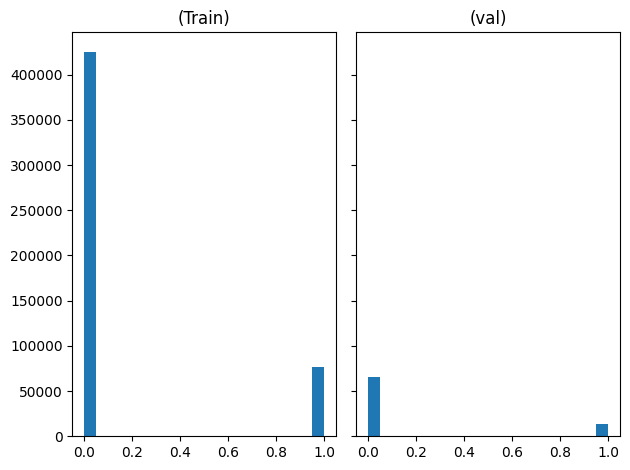

In [90]:
plt.figure(figsize=(3, 3))
fig, axs = plt.subplots(1, 2, sharey=True, tight_layout=True)
axs[0].hist(y_train, bins=20)
axs[0].set_title('(Train)')
axs[1].hist(y_val, bins=20)
axs[1].set_title('(val)')

In [91]:
videoname2AH=videoname2AH_val
for videoname in videoname2AH:
    frame2ind={}
    for ind,frame in enumerate(videoname2img_names[videoname]):
        frame2ind[frame]=ind
    y=[]
    for frame,AH in content[videoname]['frame_annotation']:
        ind=frame2ind[frame]
        y.append(AH)
    
    num_trainsitions01=0
    for frame in range(1,len(y)):
        if y[frame-1]==0 and y[frame]==1:
            num_trainsitions01+=1
    print(videoname,videoname2AH[videoname],np.mean(y),num_trainsitions01)


Videos/82813/Visite_1/82813_Question_3_2025-01-31_19-18-58_Video.mp4 0 0.0 0
Videos/82813/Visite_1/82813_Question_4_2025-01-31_19-17-45_Video.mp4 1 0.19872476089266738 2
Videos/82813/Visite_1/82813_Question_6_2025-01-31_19-20-49_Video.mp4 0 0.0 0
Videos/82813/Visite_1/82813_Question_7_2025-01-31_19-19-23_Video.mp4 0 0.0 0
Videos/82603/Visite_1/82603_Question_1_2024-11-01_23-46-28_Video.mp4 1 0.25787106446776614 3
Videos/82603/Visite_1/82603_Question_2_2024-11-01_23-48-59_Video.mp4 1 0.23369565217391305 2
Videos/82603/Visite_1/82603_Question_3_2024-11-01_23-48-00_Video.mp4 1 0.06428571428571428 1
Videos/82603/Visite_1/82603_Question_4_2024-11-01_23-50-07_Video.mp4 1 0.0 0
Videos/82603/Visite_1/82603_Question_5_2024-11-01_23-51-55_Video.mp4 1 0.1946808510638298 1
Videos/82603/Visite_1/82603_Question_6_2024-11-01_23-53-02_Video.mp4 0 0.0 0
Videos/82603/Visite_1/82603_Question_7_2024-11-01_23-50-53_Video.mp4 1 0.5761467889908257 3
Videos/82851/Visite_1/82851_Question_1_2025-02-18_19-07-02_

In [92]:
videoname2AH=videoname2AH_train
for videoname in videoname2AH:
    frame2ind={}
    for ind,frame in enumerate(videoname2img_names[videoname]):
        frame2ind[frame]=ind
    y=[]
    for frame,AH in content[videoname]['frame_annotation']:
        ind=frame2ind[frame]
        y.append(AH)
    print(videoname,videoname2AH[videoname],np.mean(y))


Videos/82782/Visite_1/82782_Question_2_2024-12-09_17-16-53_Video.mp4 0 0.0
Videos/82866/Visite_1/82866_Question_1_2025-02-20_14-54-02_Video.mp4 0 0.0
Videos/82781/Visite_1/82781_Question_4_2024-12-09_15-50-43_Video.mp4 0 0.0
Videos/82674/Visite_1/82674_Question_1_2024-11-13_21-11-23_Video.mp4 0 0.0
Videos/82750/Visite_1/82750_Question_5_2024-11-28_01-13-30_Video.mp4 1 0.22045454545454546
Videos/82696/Visite_1/82696_Question_4_2024-11-16_10-52-14_Video.mp4 1 0.4518950437317784
Videos/82725/Visite_1/82725_Question_2_2024-11-19_15-16-46_Video.mp4 1 0.5657142857142857
Videos/82751/Visite_1/82751_Question_5_2024-11-28_01-42-03_Video.mp4 1 0.3417989417989418
Videos/82709/Visite_1/82709_Question_3_2024-11-18_15-20-30_Video.mp4 0 0.0
Videos/82815/Visite_1/82815_Question_2_2025-01-31_22-24-13_Video.mp4 1 0.3366733466933868
Videos/82609/Visite_1/82609_Question_3_2024-11-02_17-56-15_Video.mp4 0 0.0
Videos/82783/Visite_1/82783_Question_6_2024-12-09_22-57-33_Video.mp4 0 0.0
Videos/82781/Visite_1/82

82632/Visite_1/82632_Question_2_2024-11-06_14-32-20_Video.mp4 1 0.550351288056206
82696/Visite_1/82696_Question_3_2024-11-16_10-52-54_Video.mp4 1 0.3554817275747508
82628/Visite_1/82628_Question_1_2024-11-06_12-08-39_Video.mp4 1 0.1740041928721174
82704/Visite_1/82704_Question_3_2024-11-18_13-35-43_Video.mp4 1 0.5277044854881267
82695/Visite_1/82695_Question_4_2024-11-16_08-56-02_Video.mp4 1 0.48727272727272725
82650/Visite_1/82650_Question_6_2024-11-13_00-36-58_Video.mp4 0 0.0
82566/Visite 1/82566_Question_2_2024-10-02 15-45-31_Video.mp4 1 0.15723270440251572
82658/Visite_1/82658_Question_1_2024-11-13_11-52-05_Video.mp4 0 0.0
82654/Visite_1/82654_Question_6_2024-11-13_08-19-48_Video.mp4 0 0.0
82708/Visite_1/82708_Question_4_2024-11-18_15-02-13_Video.mp4 1 0.4448979591836735
82621/Visite_1/82621_Question_6_2024-11-05_15-00-16_Video.mp4 1 0.13793103448275862
82633/Visite_1/82633_Question_1_2024-11-06_15-28-28_Video.mp4 0 0.0
82612/Visite_1/82612_Question_7_2024-11-04_12-31-55_Video.mp4 

In [93]:
print('train',np.unique(list(videoname2AH_train.values()),return_counts=True))
print('val',np.unique(list(videoname2AH_val.values()),return_counts=True))

train (array([0, 1]), array([393, 385]))
val (array([0, 1]), array([49, 75]))


# Learning

## RandomForestClassifier

In [6]:
np.random.seed(1)
res=RandomForestClassifier(n_estimators=1000,max_depth=3, n_jobs=-1)
#res=svm.LinearSVC(C=1)
#import xgboost as xgb
#res=xgb.XGBRegressor(n_estimators=10)
#clf = xgb.XGBClassifier(n_estimators=1000,use_label_encoder=False)

res.fit(X_train, y_train)
y_val_preds = res.predict(X_val)
print(y_val_preds.shape)
print(f1_score(y_val,y_val_preds,average='weighted'))

(79538,)
0.744784738353578


In [6]:
if False:
    with open('random_forest_model.pkl', 'wb') as f:
        pickle.dump(res, f)
else:    
    with open('random_forest_model.pkl', 'rb') as f:
        res = pickle.load(f)

In [30]:
y_val_preds = res.predict_proba(X_val)
print(y_val_preds.shape)
for t in np.linspace(0,0.9,19):
    new_pred = (y_val_preds[:,1] >= t)
    print(f"{t:.2f}, {f1_score(y_val,new_pred,average='weighted'):.4f}, {f1_score(y_val,new_pred,average='macro'):.4f}, {accuracy_score(y_val,new_pred):.4f}")

(79538, 2)
0.00, 0.0526, 0.1495, 0.1758
0.05, 0.0526, 0.1495, 0.1758
0.10, 0.2817, 0.2979, 0.2988
0.15, 0.6690, 0.5429, 0.6256
0.20, 0.7717, 0.6015, 0.7743
0.25, 0.7796, 0.5652, 0.8166
0.30, 0.7448, 0.4518, 0.8242
0.35, 0.7448, 0.4518, 0.8242
0.40, 0.7448, 0.4518, 0.8242
0.45, 0.7448, 0.4518, 0.8242
0.50, 0.7448, 0.4518, 0.8242
0.55, 0.7448, 0.4518, 0.8242
0.60, 0.7448, 0.4518, 0.8242
0.65, 0.7448, 0.4518, 0.8242
0.70, 0.7448, 0.4518, 0.8242
0.75, 0.7448, 0.4518, 0.8242
0.80, 0.7448, 0.4518, 0.8242
0.85, 0.7448, 0.4518, 0.8242
0.90, 0.7448, 0.4518, 0.8242


In [32]:
y_val_preds = res.predict_proba(X_val)
print(y_val_preds.shape)
for t in np.linspace(0.2,0.3,11):
    new_pred = (y_val_preds[:,1] >= t)
    print(f"{t:.2f}, {f1_score(y_val,new_pred,average='weighted'):.4f}, {f1_score(y_val,new_pred,average='macro'):.4f}, {accuracy_score(y_val,new_pred):.4f}")

(79538, 2)
0.20, 0.7717, 0.6015, 0.7743
0.21, 0.7802, 0.6050, 0.7899
0.22, 0.7796, 0.5975, 0.7935
0.23, 0.7771, 0.5834, 0.7975
0.24, 0.7764, 0.5719, 0.8041
0.25, 0.7796, 0.5652, 0.8166
0.26, 0.7741, 0.5457, 0.8187
0.27, 0.7674, 0.5234, 0.8206
0.28, 0.7601, 0.4984, 0.8232
0.29, 0.7448, 0.4519, 0.8242
0.30, 0.7448, 0.4518, 0.8242


---------------------

## Multimodal MLP

In [21]:
if True: # загружено на Preprocess
    with open(FEATURES_PICKLE, 'rb') as handle:
        X_train, y_train, X_val, y_val = pickle.load(handle)

    # Convert to torch tensors
    X_train = torch.from_numpy(X_train).float()
    y_train = torch.from_numpy(y_train).float().unsqueeze(1)  # shape (n,1)
    X_val = torch.from_numpy(X_val).float()
    y_val = torch.from_numpy(y_val).float().unsqueeze(1)

y_train_np = y_train.detach().cpu().numpy().astype(int).ravel()
neg, pos = np.bincount(y_train_np)
pos_weight = torch.tensor([neg / pos], dtype=torch.float32).to(device)
print(f'class ratio {neg}:{pos}, pos_weight={pos_weight.item():.2f}')

class ratio 425468:76502, pos_weight=5.56


In [46]:
# Create DataLoaders
batch_size = 512
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# -------------------------------
# 2. Define the MLP model
# -------------------------------
class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        #x = self.sigmoid(self.fc2(x))
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MLP(X_train.shape[1]).to(device)

In [28]:
# -------------------------------
# 3. Loss, optimizer, and training setup
# -------------------------------
# criterion = nn.BCELoss()   # binary cross-entropy (expects probabilities)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=5e-4)

num_epochs = 20   # change as needed
best_val_f1 = -1.0
best_model_state = None

# -------------------------------
# 4. Training loop with best model saving (based on val F1)
# -------------------------------
for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)
    train_loss /= len(train_loader.dataset)

    # Validation phase
    model.eval()
    val_preds = []
    val_true = []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            preds = torch.sigmoid(outputs).cpu().numpy() # preds = outputs.cpu().numpy()
            
            val_preds.extend(preds)
            val_true.extend(y_batch.cpu().numpy())
    val_preds = np.array(val_preds).flatten()
    val_true = np.array(val_true).flatten()
    
    # Compute F1 score (weighted) using a threshold of 0.5
    val_pred_binary = (val_preds >= 0.5).astype(int)
    val_f1 = f1_score(val_true, val_pred_binary, average='weighted')
    val_f1_macro = f1_score(val_true, val_pred_binary, average='macro')
    
    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f} - Val F1: {val_f1:.4f} - Val F1_macro: {val_f1_macro:.4f}")

    # Save best model based on validation F1 (maximize)
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        torch.save(best_model_state, 'best_model_Multimodal_MLP.pth')  
        print(f"  -> New best model saved (F1 = {val_f1:.4f})")

Epoch 1/20 - Train Loss: 0.8638 - Val F1: 0.7313 - Val F1_macro: 0.5947
  -> New best model saved (F1 = 0.7313)
Epoch 2/20 - Train Loss: 0.6776 - Val F1: 0.7699 - Val F1_macro: 0.6076
  -> New best model saved (F1 = 0.7699)
Epoch 3/20 - Train Loss: 0.5816 - Val F1: 0.7707 - Val F1_macro: 0.6050
  -> New best model saved (F1 = 0.7707)
Epoch 4/20 - Train Loss: 0.5172 - Val F1: 0.7624 - Val F1_macro: 0.5991
Epoch 5/20 - Train Loss: 0.4695 - Val F1: 0.7629 - Val F1_macro: 0.5940
Epoch 6/20 - Train Loss: 0.4314 - Val F1: 0.7691 - Val F1_macro: 0.5944
Epoch 7/20 - Train Loss: 0.3997 - Val F1: 0.7620 - Val F1_macro: 0.5880
Epoch 8/20 - Train Loss: 0.3735 - Val F1: 0.7613 - Val F1_macro: 0.5952
Epoch 9/20 - Train Loss: 0.3499 - Val F1: 0.7728 - Val F1_macro: 0.5988
  -> New best model saved (F1 = 0.7728)
Epoch 10/20 - Train Loss: 0.3287 - Val F1: 0.7432 - Val F1_macro: 0.5862
Epoch 11/20 - Train Loss: 0.3123 - Val F1: 0.7601 - Val F1_macro: 0.5871
Epoch 12/20 - Train Loss: 0.2961 - Val F1: 0.7

In [49]:
# -------------------------------
# 5. Restore best model and evaluate
# -------------------------------
def print_metrics(model, data_loader, device):
    model.eval()
    y_preds = []
    y_true = []
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            proba = torch.sigmoid(outputs)
            y_preds.extend(proba.cpu().numpy())
            y_true.extend(y_batch.numpy())
    y_preds = np.array(y_preds).flatten()
    y_true = np.array(y_true).flatten()
    y_pred_binary = (y_preds >= 0.5).astype(int)
    f1 = f1_score(y_true, y_pred_binary, average='weighted')
    f1_macro = f1_score(y_true, y_pred_binary, average='macro')
    print(f"F1 Score (weighted, threshold=0.5): {f1:.4f}")
    print(f"F1 Score (macro, threshold=0.5): {f1_macro:.4f}")
    return y_preds, y_true

In [35]:
print("\n--- Evaluating best model ---")
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    model.to(device)
    y_val_preds, y_val_true = print_metrics(model, val_loader, device)
else:
    print("No best model saved, using final model.")
    y_val_preds, y_val_true = print_metrics(model, val_loader, device)

# -------------------------------
# 6. Threshold search (0 to 0.9)
# -------------------------------
print("\n--- Threshold search ---")
for t in np.linspace(0, 1, 11):
    y_pred_t = (y_val_preds >= t).astype(int)
    f1_t = f1_score(y_val_true, y_pred_t, average='weighted')
    f1_macro_t = f1_score(y_val_true, y_pred_t, average='macro')
    print(f"{t:.2f} -> F1: {f1_t:.4f}, F1: {f1_macro_t:.4f}")


--- Evaluating best model ---
F1 Score (weighted, threshold=0.5): 0.7728
F1 Score (macro, threshold=0.5): 0.5988

--- Threshold search ---
0.00 -> F1: 0.0526, F1: 0.1495
0.10 -> F1: 0.7059, F1: 0.5702
0.20 -> F1: 0.7365, F1: 0.5874
0.30 -> F1: 0.7537, F1: 0.5958
0.40 -> F1: 0.7656, F1: 0.5999
0.50 -> F1: 0.7728, F1: 0.5988
0.60 -> F1: 0.7769, F1: 0.5927
0.70 -> F1: 0.7788, F1: 0.5826
0.80 -> F1: 0.7759, F1: 0.5625
0.90 -> F1: 0.7688, F1: 0.5304
1.00 -> F1: 0.7448, F1: 0.4518


In [47]:
PT_MODEL_MLP = 'best_model_Multimodal_MLP.pth'

if True: 
    model = MLP(X_train.shape[1]).to(device)
    model.load_state_dict(torch.load(PT_MODEL_MLP, map_location=device))
    print('loaded', PT_MODEL_MLP)

loaded best_model_Multimodal_MLP.pth


In [50]:
y_val_preds, y_val_true = print_metrics(model, val_loader, device)

F1 Score (weighted, threshold=0.5): 0.7728
F1 Score (macro, threshold=0.5): 0.5988


## Ensemble

In [12]:
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        return self.fc2(x)  # logits, без sigmoid

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


In [13]:
# Отдельные MLP: faces/audio/text

ENSEMBLE_STEP = 1  # step для val, как в get_concat_features2targets

if 'device' not in globals():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [15]:
def _pos_weight_from_labels(y_np):
    y_np = np.asarray(y_np, dtype=np.int64).ravel()
    neg, pos = np.bincount(y_np)
    return torch.tensor([neg / pos], dtype=torch.float32, device=device)

In [14]:
def train_mlp_pt(X_train_np, y_train_np, X_val_np, y_val_np, num_epochs=10, lr=5e-4, batch_size=512):
    X_tr = torch.from_numpy(np.asarray(X_train_np, dtype=np.float32))
    y_tr = torch.from_numpy(np.asarray(y_train_np, dtype=np.float32)).unsqueeze(1)
    X_va = torch.from_numpy(np.asarray(X_val_np, dtype=np.float32))
    y_va = torch.from_numpy(np.asarray(y_val_np, dtype=np.float32)).unsqueeze(1)

    train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_va, y_va), batch_size=batch_size, shuffle=False)

    pos_weight = _pos_weight_from_labels(y_train_np)
    print(f'  pos_weight={pos_weight.item():.2f}, input_dim={X_tr.shape[1]}')

    model = MLP(X_tr.shape[1]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_val_f1 = -1.0
    best_state = None

    for epoch in range(num_epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

        model.eval()
        val_preds, val_true = [], []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                logits = model(X_batch.to(device))
                val_preds.extend(torch.sigmoid(logits).cpu().numpy().flatten())
                val_true.extend(y_batch.numpy().flatten())

        val_f1 = f1_score(val_true, (np.array(val_preds) >= 0.5).astype(int), average='weighted')
        val_f1_macro = f1_score(val_true, (np.array(val_preds) >= 0.5).astype(int), average='macro')
        print(f'  epoch {epoch + 1}/{num_epochs} val_f1={val_f1:.4f} macro={val_f1_macro:.4f}')

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print(f'safe_best_state')

    if best_state is not None:
        model.load_state_dict(best_state)
    return model

In [14]:
@torch.no_grad()
def predict_mlp_pt(model, X_np, batch_size=512):
    model.eval()
    X_np = np.asarray(X_np, dtype=np.float32)
    preds = []
    for start in range(0, len(X_np), batch_size):
        X_batch = torch.from_numpy(X_np[start:start + batch_size]).float().to(device)
        logits = model(X_batch)
        preds.extend(torch.sigmoid(logits).cpu().numpy().flatten())
    return np.array(preds)

In [43]:
print('faces')
X_train_faces, y_train_faces = get_video2targets(videoname2features, videoname2AH_train, step=ENSEMBLE_STEP)
X_val_faces, y_val_faces = get_video2targets(videoname2features, videoname2AH_val, step=ENSEMBLE_STEP)

PT_MODEL_FACES = 'bah_pt_faces.pt'

faces
(501970, 1280) (501970,)
(79538, 1280) (79538,)


In [33]:
if False:
    num_epochs = 10
    print('train faces')
    model_faces = train_mlp_pt(X_train_faces, y_train_faces, X_val_faces, y_val_faces, num_epochs=num_epochs)
    torch.save(model_faces.state_dict(), PT_MODEL_FACES)
    print('saved', PT_MODEL_FACES)

train faces
  pos_weight=5.56, input_dim=1280
  epoch 1/10 val_f1=0.6814 macro=0.4895
  epoch 2/10 val_f1=0.6805 macro=0.4957
  epoch 3/10 val_f1=0.6647 macro=0.4970
  epoch 4/10 val_f1=0.6973 macro=0.5085
  epoch 5/10 val_f1=0.6715 macro=0.4989
  epoch 6/10 val_f1=0.6883 macro=0.5064
  epoch 7/10 val_f1=0.6897 macro=0.5074
  epoch 8/10 val_f1=0.6690 macro=0.4997
  epoch 9/10 val_f1=0.6804 macro=0.5056
  epoch 10/10 val_f1=0.7063 macro=0.5192
saved bah_pt_faces.pt


In [16]:
faces_input_dim = 1280
PT_MODEL_FACES = 'bah_pt_faces.pt'

In [26]:
if True:  # False — загрузить .pt без переобучения
    model_faces = MLP(faces_input_dim).to(device) # MLP(X_train_faces.shape[1]).to(device)
    model_faces.load_state_dict(torch.load(PT_MODEL_FACES, map_location=device))
    print('loaded', PT_MODEL_FACES)

loaded bah_pt_faces.pt


In [44]:
print('audio')
X_train_audio, y_train_audio = get_video2targets(videoname2audio_features_sampled, videoname2AH_train, step=ENSEMBLE_STEP)
X_val_audio, y_val_audio = get_video2targets(videoname2audio_features_sampled, videoname2AH_val, step=ENSEMBLE_STEP)

PT_MODEL_AUDIO = 'bah_pt_audio.pt'

audio
(501970, 1024) (501970,)
(79538, 1024) (79538,)


In [38]:
if False:
    num_epochs = 10
    print('train audio')
    model_audio = train_mlp_pt(X_train_audio, y_train_audio, X_val_audio, y_val_audio, num_epochs=num_epochs)
    torch.save(model_audio.state_dict(), PT_MODEL_AUDIO)
    print('saved', PT_MODEL_AUDIO)

train audio
  pos_weight=5.56, input_dim=1024
  epoch 1/10 val_f1=0.5420 macro=0.4577
  epoch 2/10 val_f1=0.6119 macro=0.4992
  epoch 3/10 val_f1=0.5449 macro=0.4621
  epoch 4/10 val_f1=0.6368 macro=0.5125
  epoch 5/10 val_f1=0.6338 macro=0.5125
  epoch 6/10 val_f1=0.6528 macro=0.5218
  epoch 7/10 val_f1=0.6105 macro=0.4985
  epoch 8/10 val_f1=0.6559 macro=0.5221
  epoch 9/10 val_f1=0.6394 macro=0.5151
  epoch 10/10 val_f1=0.6676 macro=0.5295
saved bah_pt_audio.pt


In [17]:
audio_input_dim = 1024
PT_MODEL_AUDIO = 'bah_pt_audio.pt'

In [25]:
if True:
    model_audio = MLP(audio_input_dim).to(device) # MLP(X_train_audio.shape[1]).to(device)
    model_audio.load_state_dict(torch.load(PT_MODEL_AUDIO, map_location=device))
    print('loaded', PT_MODEL_AUDIO)

loaded bah_pt_audio.pt


In [45]:
print('text')
X_train_text, y_train_text = get_video2targets(videoname2text_features_sampled, videoname2AH_train, step=ENSEMBLE_STEP)
X_val_text, y_val_text = get_video2targets(videoname2text_features_sampled, videoname2AH_val, step=ENSEMBLE_STEP)

PT_MODEL_TEXT = 'bah_pt_text.pt'

text
(501970, 768) (501970,)
(79538, 768) (79538,)


In [16]:
if False: 
    num_epochs = 10
    model_text = train_mlp_pt(X_train_text, y_train_text, X_val_text, y_val_text, num_epochs=num_epochs)
    torch.save(model_text.state_dict(), PT_MODEL_TEXT)
    print('saved', PT_MODEL_TEXT)

#   pos_weight=5.56, input_dim=768
#   epoch 1/10 val_f1=0.7340 macro=0.5894
#   epoch 2/10 val_f1=0.7568 macro=0.5857
#   epoch 3/10 val_f1=0.7484 macro=0.5858
#   epoch 4/10 val_f1=0.7529 macro=0.5944
#   epoch 5/10 val_f1=0.7641 macro=0.5643
#   epoch 6/10 val_f1=0.7511 macro=0.5963
#   epoch 7/10 val_f1=0.7673 macro=0.5902
#   epoch 8/10 val_f1=0.7456 macro=0.5752
#   epoch 9/10 val_f1=0.7662 macro=0.5873
#   epoch 10/10 val_f1=0.7633 macro=0.5809
# saved bah_pt_text.pt

In [18]:
text_input_dim = 768
PT_MODEL_TEXT = 'bah_pt_text.pt'

In [19]:
if True:
    model_text = MLP(text_input_dim).to(device) # MLP(X_train_text.shape[1]).to(device)
    model_text.load_state_dict(torch.load(PT_MODEL_TEXT, map_location=device))
    print('loaded', PT_MODEL_TEXT)

loaded bah_pt_text.pt


In [46]:
y_val_ensemble = y_val_faces

In [47]:
# --- val predict ---
y_val_preds_video = predict_mlp_pt(model_faces, X_val_faces)
y_val_preds_audio = predict_mlp_pt(model_audio, X_val_audio)
y_val_preds_text = predict_mlp_pt(model_text, X_val_text)

f1_video = f1_score(y_val_ensemble, (y_val_preds_video >= 0.5).astype(int), average='weighted')
f1_audio = f1_score(y_val_ensemble, (y_val_preds_audio >= 0.5).astype(int), average='weighted')
f1_text  = f1_score(y_val_ensemble, (y_val_preds_text >= 0.5).astype(int), average='weighted')

f1_video_macro = f1_score(y_val_ensemble, (y_val_preds_video >= 0.5).astype(int), average='macro')
f1_audio_macro = f1_score(y_val_ensemble, (y_val_preds_audio >= 0.5).astype(int), average='macro')
f1_text_macro  = f1_score(y_val_ensemble, (y_val_preds_text >= 0.5).astype(int), average='macro')

print(f'single modality F1 @0.5 (weighted): video={f1_video:.4f}, audio={f1_audio:.4f}, text={f1_text:.4f}')
print(f'single modality F1 @0.5 (macro): video={f1_video_macro:.4f}, audio={f1_audio_macro:.4f}, text={f1_text:.4f}')

single modality F1 @0.5 (weighted): video=0.7063, audio=0.6676, text=0.7673
single modality F1 @0.5 (macro): video=0.5192, audio=0.5295, text=0.7673


In [46]:
# --- подбор threshold для каждой модальности отдельно ---

modalities = {
    'faces': y_val_preds_video,
    'audio': y_val_preds_audio,
    'text': y_val_preds_text,
}

thresholds = np.linspace(0.0, 1.0, 21)
best_t = {}

for name, proba in modalities.items():
    print(f'\n{"="*60}')
    print(name)
    best = dict(weighted=-1, macro=-1)
    for t in thresholds:
        pred = (proba >= t).astype(int)
        f1_w = f1_score(y_val_ensemble, pred, average='weighted')
        f1_m = f1_score(y_val_ensemble, pred, average='macro')
        acc  = accuracy_score(y_val_ensemble, pred)
        f1_1 = f1_score(y_val_ensemble, pred, pos_label=1, zero_division=0)

        if f1_w > best['weighted']:
            best['weighted'] = f1_w
            best['t_weighted'] = t
        if f1_m > best['macro']:
            best['macro'] = f1_m
            best['t_macro'] = t
        print(f'{t:.2f}  {f1_w:.4f}  {f1_m:.4f}  {acc:.4f}  {f1_1:.4f}')

    print(f'best by weighted: t={best["t_weighted"]:.2f}, f1={best["weighted"]:.4f}')
    print(f'best by macro:    t={best["t_macro"]:.2f}, f1={best["macro"]:.4f}')

    best_t[name] = best

# удобные переменные для дальнейшего использования
T_VIDEO = best_t['faces']['t_weighted']
T_AUDIO = best_t['audio']['t_weighted']
T_TEXT  = best_t['text']['t_weighted']

print(f'\nrecommended thresholds (weighted): video={T_VIDEO:.2f}, audio={T_AUDIO:.2f}, text={T_TEXT:.2f}')


faces
0.00  0.0526  0.1495  0.1758  0.2990
0.05  0.3908  0.3559  0.3604  0.3022
0.10  0.4944  0.4155  0.4408  0.2937
0.15  0.5506  0.4457  0.4929  0.2840
0.20  0.5901  0.4666  0.5346  0.2762
0.25  0.6177  0.4793  0.5668  0.2658
0.30  0.6419  0.4915  0.5972  0.2597
0.35  0.6633  0.5028  0.6260  0.2552
0.40  0.6798  0.5093  0.6502  0.2464
0.45  0.6947  0.5163  0.6728  0.2411
0.50  0.7063  0.5192  0.6923  0.2306
0.55  0.7168  0.5221  0.7108  0.2218
0.60  0.7253  0.5225  0.7274  0.2098
0.65  0.7325  0.5212  0.7430  0.1953
0.70  0.7378  0.5177  0.7566  0.1782
0.75  0.7421  0.5128  0.7695  0.1592
0.80  0.7445  0.5036  0.7817  0.1321
0.85  0.7466  0.4931  0.7946  0.1021
0.90  0.7468  0.4787  0.8067  0.0653
0.95  0.7464  0.4636  0.8181  0.0276
1.00  0.7448  0.4518  0.8242  0.0000
best by weighted: t=0.90, f1=0.7468
best by macro:    t=0.60, f1=0.5225

audio
0.00  0.0526  0.1495  0.1758  0.2990
0.05  0.1576  0.2185  0.2298  0.3123
0.10  0.2140  0.2551  0.2605  0.3185
0.15  0.2700  0.2909  0.29

In [53]:
# --- подбор весов w1, w2, threshold ---
best_f1 = 0.0
best_w1, best_w2, best_t = 0.0, 0.0, 0.0
for w1 in np.arange(0.0, 0.95, 0.05):
    for w2 in np.arange(0.0, 1 - w1, 0.05):
        y_ensemble = (
            w1 * y_val_preds_video
            + w2 * y_val_preds_audio
            + (1 - w1 - w2) * y_val_preds_text
        )
        for t in [0.2, 0.3, 0.4, 0.5, 0.55, 0.6, 0.65, 0.7]:
            f1 = f1_score(y_val_faces, (y_ensemble >= t).astype(int), average='weighted')
            f1_macro = f1_score(y_val_ensemble, (y_ensemble >= t).astype(int), average='macro')
            # print(f'w1 {w1:.2f}, w2 {w2:.2f}, w3 {1 - w1 - w2:.2f},  t {t:.2f},  f1 {f1:.4f}, f1_macro {f1_macro:.4f}')
            if f1 > best_f1:
                best_f1 = f1
                best_w1, best_w2, best_t = w1, w2, t
                best_f1_macro = f1_macro

print(f'best_w1 {best_w1:.2f}, best_w2 {best_w2:.2f}, best_t {best_t:.2f}, best_f1 {best_f1:.4f}, f1_macro {best_f1_macro:.4f}')

best_w1 0.15, best_w2 0.50, best_t 0.55, best_f1 0.7850, f1_macro 0.5933


### Smoothing

In [60]:
# Smoothing + перебор delta/threshold на val

if 'best_w1' not in globals():
    best_w1, best_w2, best_t = 0.15, 0.5, 0.55

deltas = [0, 5, 10, 20, 30, 40, 50, 60, 70, 80, 100, 150]
y_val_np = np.asarray(y_val_ensemble, dtype=np.int64)

total_preds = [[] for _ in range(len(deltas))]
for videoname in videoname2AH_val:
    frame2ind = {frame: ind for ind, frame in enumerate(videoname2img_names[videoname])}
    video_features = videoname2features[videoname]
    audio_features = videoname2audio_features_sampled[videoname]
    text_features = videoname2text_features_sampled[videoname]

    X_video, X_audio, X_text = [], [], []
    for frame, AH in content[videoname]['frame_annotation']:
        ind = frame2ind[frame]
        X_video.append(video_features[ind])
        X_audio.append(audio_features[ind])
        X_text.append(text_features[ind])

    preds_video = predict_mlp_pt(model_faces, np.array(X_video))
    preds_audio = predict_mlp_pt(model_audio, np.array(X_audio))
    preds_text = predict_mlp_pt(model_text, np.array(X_text))
    y_ensemble = (
        best_w1 * preds_video
        + best_w2 * preds_audio
        + (1 - best_w1 - best_w2) * preds_text
    )

    for hInd, delta in enumerate(deltas):
        for i in range(len(y_ensemble)):
            i1 = max(i - delta, 0)
            proba = np.mean(y_ensemble[i1:i + delta + 1])
            total_preds[hInd].append(proba)

best_smooth = (0, 0.0, 0.0)
for hInd, delta in enumerate(deltas):
    for t in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
        new_pred = (np.array(total_preds[hInd]) >= t).astype(int)
        f1_w = f1_score(y_val_np, new_pred, average='weighted')
        f1_m = f1_score(y_val_np, new_pred, average='macro')
        print(f'{delta}, {t}, {f1_w:.4f}, {f1_m:.4f}')
        if f1_w > best_smooth[2]:
            best_smooth = (delta, t, f1_w, f1_m)
    print()

print(f'best delta: {best_smooth[0]}, threshold: {best_smooth[1]}, weighted_f1: {best_smooth[2]:.4f}, macro_f1: {best_smooth[3]:.4f}')

0, 0.2, 0.4204, 0.3872
0, 0.3, 0.6189, 0.5154
0, 0.4, 0.7394, 0.5934
0, 0.5, 0.7810, 0.6064
0, 0.6, 0.7806, 0.5673
0, 0.7, 0.7568, 0.4890

5, 0.2, 0.3890, 0.3681
5, 0.3, 0.6287, 0.5233
5, 0.4, 0.7526, 0.6059
5, 0.5, 0.7844, 0.6091
5, 0.6, 0.7806, 0.5624
5, 0.7, 0.7524, 0.4755

10, 0.2, 0.3790, 0.3626
10, 0.3, 0.6344, 0.5285
10, 0.4, 0.7561, 0.6096
10, 0.5, 0.7861, 0.6104
10, 0.6, 0.7794, 0.5576
10, 0.7, 0.7512, 0.4723

20, 0.2, 0.3584, 0.3494
20, 0.3, 0.6356, 0.5289
20, 0.4, 0.7606, 0.6153
20, 0.5, 0.7858, 0.6094
20, 0.6, 0.7764, 0.5488
20, 0.7, 0.7485, 0.4647

30, 0.2, 0.3438, 0.3389
30, 0.3, 0.6379, 0.5303
30, 0.4, 0.7633, 0.6196
30, 0.5, 0.7867, 0.6097
30, 0.6, 0.7757, 0.5454
30, 0.7, 0.7467, 0.4597

40, 0.2, 0.3302, 0.3295
40, 0.3, 0.6371, 0.5277
40, 0.4, 0.7656, 0.6218
40, 0.5, 0.7884, 0.6115
40, 0.6, 0.7740, 0.5406
40, 0.7, 0.7464, 0.4587

50, 0.2, 0.3210, 0.3229
50, 0.3, 0.6379, 0.5267
50, 0.4, 0.7675, 0.6236
50, 0.5, 0.7897, 0.6132
50, 0.6, 0.7697, 0.5305
50, 0.7, 0.7456, 0.456

## Result

In [36]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix)

def eval_binary(y_true, y_proba, threshold=0.5, name='model'):
    y_true = np.asarray(y_true, dtype=int).ravel()
    y_pred = (np.asarray(y_proba).ravel() >= threshold).astype(int)

    print(f'{name}  |  threshold={threshold:.2f}')

    print('\nconfusion_matrix')
    print(f'[TN, FP] : {confusion_matrix(y_true, y_pred)[0]}')
    print(f'[FN, TP] : {confusion_matrix(y_true, y_pred)[1]}')
    print(f"\n{classification_report(y_true, y_pred, target_names=['(0)', '(1)'], digits=4, zero_division=0)}")
    #return y_pred

In [12]:
#y_val_np = np.asarray(y_val_ensemble, dtype=int).ravel()
y_val_np = np.asarray(y_val, dtype=int).ravel()
print('val shape', y_val_np.shape, 'class counts', np.bincount(y_val_np))

val shape (79538,) class counts [65556 13982]


In [86]:
# 0) always 0
eval_binary(y_val_np, np.zeros(len(y_val_np)), threshold=0.5, name='baseline: always 0')

baseline: always 0  |  threshold=0.50

confusion_matrix
[TN, FP] : [65556     0]
[FN, TP] : [13982     0]

              precision    recall  f1-score   support

         (0)     0.8242    1.0000    0.9036     65556
         (1)     0.0000    0.0000    0.0000     13982

    accuracy                         0.8242     79538
   macro avg     0.4121    0.5000    0.4518     79538
weighted avg     0.6793    0.8242    0.7448     79538



In [13]:
# 1) Random Forest
if True:
    with open('random_forest_model.pkl', 'rb') as f:
        res = pickle.load(f)
rf_proba = res.predict_proba(X_val)[:, 1]
RF_T = 0.21
eval_binary(y_val_np, rf_proba, threshold=RF_T, name='RandomForest')

RandomForest  |  threshold=0.21

confusion_matrix
[TN, FP] : [58621  6935]
[FN, TP] : [9776 4206]

              precision    recall  f1-score   support

         (0)     0.8571    0.8942    0.8752     65556
         (1)     0.3775    0.3008    0.3348     13982

    accuracy                         0.7899     79538
   macro avg     0.6173    0.5975    0.6050     79538
weighted avg     0.7728    0.7899    0.7802     79538



In [29]:
# 2) Multimodal concat MLP
MULTI_T = 0.4
eval_binary(y_val_true, y_val_preds, threshold=MULTI_T, name='Multimodal MLP (concat)')

Multimodal MLP (concat)  |  threshold=0.40

confusion_matrix
[TN, FP] : [55744  9812]
[FN, TP] : [9032 4950]

              precision    recall  f1-score   support

         (0)     0.8606    0.8503    0.8554     65556
         (1)     0.3353    0.3540    0.3444     13982

    accuracy                         0.7631     79538
   macro avg     0.5979    0.6022    0.5999     79538
weighted avg     0.7682    0.7631    0.7656     79538



In [47]:
# 3) Каждая модальность отдельно
eval_binary(y_val_ensemble, y_val_preds_video, threshold=0.7, name='Ensemble / faces only')
eval_binary(y_val_ensemble, y_val_preds_audio, threshold=0.7, name='Ensemble / audio only')
eval_binary(y_val_ensemble, y_val_preds_text,  threshold=0.7, name='Ensemble / text only')

Ensemble / faces only  |  threshold=0.70

confusion_matrix
[TN, FP] : [58084  7472]
[FN, TP] : [11884  2098]

              precision    recall  f1-score   support

         (0)     0.8302    0.8860    0.8572     65556
         (1)     0.2192    0.1501    0.1782     13982

    accuracy                         0.7566     79538
   macro avg     0.5247    0.5180    0.5177     79538
weighted avg     0.7228    0.7566    0.7378     79538

Ensemble / audio only  |  threshold=0.70

confusion_matrix
[TN, FP] : [60945  4611]
[FN, TP] : [12016  1966]

              precision    recall  f1-score   support

         (0)     0.8353    0.9297    0.8800     65556
         (1)     0.2989    0.1406    0.1913     13982

    accuracy                         0.7910     79538
   macro avg     0.5671    0.5351    0.5356     79538
weighted avg     0.7410    0.7910    0.7589     79538

Ensemble / text only  |  threshold=0.70

confusion_matrix
[TN, FP] : [61380  4176]
[FN, TP] : [11350  2632]

              pre

In [48]:
# 4) Ensemble (без smoothing)
best_w1 = 0.15
best_w2 = 0.5

ens_proba = (best_w1 * y_val_preds_video + best_w2 * y_val_preds_audio + (1 - best_w1 - best_w2) * y_val_preds_text)
eval_binary(y_val_ensemble, ens_proba, threshold=0.55, name='Ensemble weighted (no smooth)')

Ensemble weighted (no smooth)  |  threshold=0.55

confusion_matrix
[TN, FP] : [61038  4518]
[FN, TP] : [10745  3237]

              precision    recall  f1-score   support

         (0)     0.8503    0.9311    0.8889     65556
         (1)     0.4174    0.2315    0.2978     13982

    accuracy                         0.8081     79538
   macro avg     0.6339    0.5813    0.5933     79538
weighted avg     0.7742    0.8081    0.7850     79538



In [50]:
# 5) Ensemble + smoothing
DELTA = 60
SMOOTH_T = 0.5
best_w1 = 0.15
best_w2 = 0.5

smooth_proba = []
for videoname in videoname2AH_val:
    frame2ind = {f: i for i, f in enumerate(videoname2img_names[videoname])}
    X_video, X_audio, X_text = [], [], []
    for frame, _ in content[videoname]['frame_annotation']:
        ind = frame2ind[frame]
        X_video.append(videoname2features[videoname][ind])   # как в train/smoothing!
        X_audio.append(videoname2audio_features_sampled[videoname][ind])
        X_text.append(videoname2text_features_sampled[videoname][ind])

    pv = predict_mlp_pt(model_faces, np.array(X_video))
    pa = predict_mlp_pt(model_audio, np.array(X_audio))
    pt = predict_mlp_pt(model_text, np.array(X_text))
    y_ens = best_w1 * pv + best_w2 * pa + (1 - best_w1 - best_w2) * pt

    for i in range(len(y_ens)):
        i1 = max(i - DELTA, 0)
        smooth_proba.append(np.mean(y_ens[i1:i + DELTA + 1]))

eval_binary(y_val_ensemble, smooth_proba, threshold=SMOOTH_T, name=f'Ensemble + smoothing (delta={DELTA}, t={SMOOTH_T})')

Ensemble + smoothing (delta=60, t=0.5)  |  threshold=0.50

confusion_matrix
[TN, FP] : [60047  5509]
[FN, TP] : [9971 4011]

              precision    recall  f1-score   support

         (0)     0.8576    0.9160    0.8858     65556
         (1)     0.4213    0.2869    0.3413     13982

    accuracy                         0.8054     79538
   macro avg     0.6395    0.6014    0.6136     79538
weighted avg     0.7809    0.8054    0.7901     79538



# Video-level eval
```
frame proba  →  video score (mean/smooth)  →  pred = score >= t  →  macro F1
```

In [19]:
# --- кадры → score на видео ---
STEP = ENSEMBLE_STEP if 'ENSEMBLE_STEP' in globals() else 1


def split_flat_proba_by_video(videoname2AH, proba_flat, step=STEP):
    """Flat-массив (порядок get_video2targets) → {videoname: [proba по кадрам]}."""
    proba_flat = np.asarray(proba_flat, dtype=np.float32).ravel()
    video2proba = {}
    idx = 0
    for videoname in videoname2AH:
        probs = []
        frame2ind = {frame: ind for ind, frame in enumerate(videoname2img_names[videoname])}
        for frame, AH in content[videoname]['frame_annotation']:
            ind = frame2ind[frame]
            if AH == 1 or ind % step == 0:
                probs.append(proba_flat[idx])
                idx += 1
        video2proba[videoname] = np.asarray(probs, dtype=np.float32)
    assert idx == len(proba_flat), f'flat length mismatch: used {idx}, got {len(proba_flat)}'
    return video2proba


def aggregate_video_score(frame_probs, agg='mean', delta=0):
    """Один score на видео: optional smoothing по кадрам + mean/max/ratio05."""
    frame_probs = np.asarray(frame_probs, dtype=np.float32)
    if len(frame_probs) == 0:
        return 0.0
    if delta > 0:
        frame_probs = np.array([
            np.mean(frame_probs[max(i - delta, 0): i + delta + 1])
            for i in range(len(frame_probs))
        ], dtype=np.float32)
    if agg == 'mean':
        return float(np.mean(frame_probs))
    if agg == 'max':
        return float(np.max(frame_probs))
    if agg == 'ratio05':
        return float(np.mean(frame_probs >= 0.5))
    raise ValueError(f'unknown agg={agg}')


def video_scores_from_flat(videoname2AH, proba_flat, agg='mean', delta=0, step=STEP):
    video2proba = split_flat_proba_by_video(videoname2AH, proba_flat, step=step)
    return {
        videoname: aggregate_video_score(probs, agg=agg, delta=delta)
        for videoname, probs in video2proba.items()
    }

print('video aggregation helpers ready')
print('val videos:', len(videoname2AH_val), 'labels:', np.bincount(list(videoname2AH_val.values())))


video aggregation helpers ready
val videos: 124 labels: [49 75]


In [41]:
# --- метрики и подбор порога на видео ---

def eval_video_level(videoname2AH, video_scores, threshold=0.5, name='video-level'):
    videonames = [v for v in videoname2AH if v in video_scores]
    y_true = np.array([videoname2AH[v] for v in videonames], dtype=int)
    y_score = np.array([video_scores[v] for v in videonames], dtype=np.float32)
    y_pred = (y_score >= threshold).astype(int)

    macro_f1 = f1_score(y_true, y_pred, average='macro')
    weighted_f1 = f1_score(y_true, y_pred, average='weighted')
    ap_pos = average_precision_score(y_true, y_score) if len(np.unique(y_true)) > 1 else 0.0

    print(f'\n{name}  |  videos={len(videonames)}  threshold={threshold:.2f}')
    print(f'macro_f1   = {macro_f1:.4f}  weighted_f1 = {weighted_f1:.4f}')
    print(f'AP(class1) = {ap_pos:.4f}  accuracy    = {accuracy_score(y_true, y_pred):.4f}')
    print('\nconfusion_matrix')
    print(f'[TN, FP] : {confusion_matrix(y_true, y_pred)[0]}')
    print(f'[FN, TP] : {confusion_matrix(y_true, y_pred)[1]}')
    print(classification_report(
        y_true, y_pred,
        target_names=['(0) - no_A/H', '(1) - A/H'],
        digits=4, zero_division=0,
    ))


def search_video_threshold(videoname2AH, video_scores, thresholds=None):
    if thresholds is None:
        thresholds = np.concatenate([np.linspace(0.0, 0.2, 21), np.linspace(0.25, 0.95, 15)])
    best_macro = (-1.0, 0.5)
    best_weighted = (-1.0, 0.5)
    for t in thresholds:
        videonames = [v for v in videoname2AH if v in video_scores]
        y_true = np.array([videoname2AH[v] for v in videonames], dtype=int)
        y_pred = (np.array([video_scores[v] for v in videonames]) >= t).astype(int)
        f1_m = f1_score(y_true, y_pred, average='macro')
        f1_w = f1_score(y_true, y_pred, average='weighted')
        if f1_m > best_macro[0]:
            best_macro = (f1_m, t)
        if f1_w > best_weighted[0]:
            best_weighted = (f1_w, t)
    return dict(
        best_macro_f1=best_macro[0], best_macro_t=best_macro[1],
        best_weighted_f1=best_weighted[0], best_weighted_t=best_weighted[1],
    )

print('video metric helpers ready')


video metric helpers ready


## Baselines на video-level

In [105]:
# baseline: всегда «нет A/H»
baseline_scores = {v: 0.0 for v in videoname2AH_val}
eval_video_level(videoname2AH_val, baseline_scores, threshold=0.5, name='baseline: always no A/H')



baseline: always no A/H  |  videos=124  threshold=0.50
macro_f1   = 0.2832  weighted_f1 = 0.2238
AP(class1) = 0.6048  accuracy    = 0.3952

confusion_matrix
[TN, FP] : [49  0]
[FN, TP] : [75  0]
              precision    recall  f1-score   support

(0) - no_A/H     0.3952    1.0000    0.5665        49
   (1) - A/H     0.0000    0.0000    0.0000        75

    accuracy                         0.3952       124
   macro avg     0.1976    0.5000    0.2832       124
weighted avg     0.1562    0.3952    0.2238       124



In [106]:
# Random Forest
if 'res' not in globals():
    with open('random_forest_model.pkl', 'rb') as f:
        res = pickle.load(f)

rf_flat = res.predict_proba(X_val)[:, 1]
rf_video_scores = video_scores_from_flat(videoname2AH_val, rf_flat, agg='mean', delta=0)
rf_search = search_video_threshold(videoname2AH_val, rf_video_scores)
print('RF best video macro:', {k: round(v, 4) if isinstance(v, float) else v for k, v in rf_search.items()})
eval_video_level(
    videoname2AH_val, rf_video_scores,
    threshold=rf_search['best_macro_t'],
    name='RandomForest video-level',
)


RF best video macro: {'best_macro_f1': 0.6653, 'best_macro_t': 0.12, 'best_weighted_f1': 0.6857, 'best_weighted_t': 0.12}

RandomForest video-level  |  videos=124  threshold=0.12
macro_f1   = 0.6653  weighted_f1 = 0.6857
AP(class1) = 0.8248  accuracy    = 0.6935

confusion_matrix
[TN, FP] : [25 24]
[FN, TP] : [14 61]
              precision    recall  f1-score   support

(0) - no_A/H     0.6410    0.5102    0.5682        49
   (1) - A/H     0.7176    0.8133    0.7625        75

    accuracy                         0.6935       124
   macro avg     0.6793    0.6618    0.6653       124
weighted avg     0.6874    0.6935    0.6857       124



In [107]:
# Multimodal concat MLP
if 'y_val_preds' not in globals():
    raise RuntimeError('Сначала обучи/загрузи Multimodal MLP и получи y_val_preds')

multi_video_scores = video_scores_from_flat(videoname2AH_val, y_val_preds, agg='mean', delta=0)
multi_search = search_video_threshold(videoname2AH_val, multi_video_scores)
print('Multimodal best video macro:', {k: round(v, 4) if isinstance(v, float) else v for k, v in multi_search.items()})
eval_video_level(
    videoname2AH_val, multi_video_scores,
    threshold=multi_search['best_macro_t'],
    name='Multimodal MLP video-level',
)


Multimodal best video macro: {'best_macro_f1': 0.683, 'best_macro_t': 0.1, 'best_weighted_f1': 0.689, 'best_weighted_t': 0.08}

Multimodal MLP video-level  |  videos=124  threshold=0.10
macro_f1   = 0.6830  weighted_f1 = 0.6889
AP(class1) = 0.8466  accuracy    = 0.6855

confusion_matrix
[TN, FP] : [37 12]
[FN, TP] : [27 48]
              precision    recall  f1-score   support

(0) - no_A/H     0.5781    0.7551    0.6549        49
   (1) - A/H     0.8000    0.6400    0.7111        75

    accuracy                         0.6855       124
   macro avg     0.6891    0.6976    0.6830       124
weighted avg     0.7123    0.6855    0.6889       124



## Ensemble: grid-search по video macro F1

```
ens_flat = w1·faces + w2·audio + (1-w1-w2)·text
video_score = mean(smooth(ens_flat on frame))
pred = video_score >= t 
```

In [108]:
# --- grid: параметры и проверка зависимостей ---

W1_VALUES = np.round(np.arange(0.0, 0.55, 0.05), 2)   # вес faces
W2_VALUES = np.round(np.arange(0.0, 0.55, 0.05), 2)   # вес audio; text = 1 - w1 - w2
VIDEO_DELTAS = [0, 10, 20, 30, 40, 50, 60, 80, 100]
VIDEO_T_VALUES = np.concatenate([
    np.linspace(0.05, 0.30, 26),
    np.linspace(0.35, 0.95, 13),
])

videonames = list(videoname2AH_val.keys())
y_true_vid = np.array([videoname2AH_val[v] for v in videonames], dtype=int)

n_w = sum(1 for w1 in W1_VALUES for w2 in W2_VALUES if w1 + w2 <= 0.95)
print(f'grid: {n_w} weight pairs × {len(VIDEO_DELTAS)} deltas × {len(VIDEO_T_VALUES)} thresholds')
print(f'  w1 in {W1_VALUES[0]:.2f}..{W1_VALUES[-1]:.2f}, w2 in {W2_VALUES[0]:.2f}..{W2_VALUES[-1]:.2f}, w1+w2 <= 0.95')


grid: 120 weight pairs × 9 deltas × 39 thresholds
  w1 in 0.00..0.50, w2 in 0.00..0.50, w1+w2 <= 0.95


In [109]:
# --- grid: перебор ---
best_grid = dict(macro_f1=-1.0, weighted_f1=-1.0, w1=0.0, w2=0.0, w3=1.0, delta=0, t=0.5)
rows_grid = []

for w1 in W1_VALUES:
    for w2 in W2_VALUES:
        if w1 + w2 > 0.95:
            continue
        w3 = 1.0 - w1 - w2
        ens_flat = w1 * y_val_preds_video + w2 * y_val_preds_audio + w3 * y_val_preds_text
        for delta in VIDEO_DELTAS:
            video_scores = video_scores_from_flat(
                videoname2AH_val, ens_flat, agg='mean', delta=delta,
            )
            score_arr = np.array([video_scores[v] for v in videonames], dtype=np.float32)
            for t in VIDEO_T_VALUES:
                y_pred = (score_arr >= t).astype(int)
                f1_m = f1_score(y_true_vid, y_pred, average='macro')
                f1_w = f1_score(y_true_vid, y_pred, average='weighted')
                rows_grid.append((w1, w2, w3, delta, float(t), f1_m, f1_w))
                if f1_m > best_grid['macro_f1']:
                    best_grid = dict(
                        macro_f1=f1_m, weighted_f1=f1_w,
                        w1=float(w1), w2=float(w2), w3=float(w3),
                        delta=delta, t=float(t),
                    )

print(f'done: {len(rows_grid)} combos evaluated')
print('best so far:', {k: round(v, 4) if isinstance(v, float) else v for k, v in best_grid.items()})

done: 42120 combos evaluated
best so far: {'macro_f1': 0.7223, 'weighted_f1': 0.7288, 'w1': 0.2, 'w2': 0.05, 'w3': 0.75, 'delta': 0, 't': 0.15}


In [110]:
# --- grid: top-15 ---
print('Top-15 by video macro F1:')
print(f'{"w1":>5} {"w2":>5} {"text":>5} {"delta":>5} {"t":>5}  {"macro":>7}  {"weighted":>8}')
for w1, w2, w3, delta, t, f1_m, f1_w in sorted(rows_grid, key=lambda x: x[5], reverse=True)[:15]:
    print(f'{w1:5.2f} {w2:5.2f} {w3:5.2f} {delta:5d} {t:5.2f}  {f1_m:7.4f}  {f1_w:8.4f}')


Top-15 by video macro F1:
   w1    w2  text delta     t    macro  weighted
 0.20  0.05  0.75     0  0.15   0.7223    0.7288
 0.20  0.05  0.75    10  0.15   0.7223    0.7288
 0.20  0.05  0.75    20  0.15   0.7223    0.7288
 0.20  0.05  0.75    30  0.15   0.7223    0.7288
 0.20  0.05  0.75    40  0.15   0.7223    0.7288
 0.20  0.05  0.75    50  0.15   0.7223    0.7288
 0.20  0.05  0.75    60  0.15   0.7223    0.7288
 0.20  0.05  0.75    80  0.15   0.7223    0.7288
 0.20  0.05  0.75   100  0.15   0.7223    0.7288
 0.10  0.25  0.65    40  0.23   0.7173    0.7197
 0.10  0.30  0.60    60  0.24   0.7168    0.7202
 0.10  0.30  0.60    80  0.24   0.7168    0.7202
 0.15  0.00  0.85     0  0.13   0.7162    0.7206
 0.15  0.00  0.85    10  0.13   0.7162    0.7206
 0.15  0.00  0.85    20  0.13   0.7162    0.7206


In [112]:
# --- grid: сравнение ---
rows_compare = []

rows_compare.append([
    f'ensemble video-grid (w1={best_grid["w1"]:.2f}, w2={best_grid["w2"]:.2f})',
    best_grid['t'], best_grid['macro_f1'],
])

if 'multi_search' in globals():
    rows_compare.append([
        'Multimodal concat MLP',
        multi_search['best_macro_t'], multi_search['best_macro_f1'],
    ])
if 'rf_search' in globals():
    rows_compare.append([
        'RandomForest',
        rf_search['best_macro_t'], rf_search['best_macro_f1'],
    ])

print(f'{"model":<45} {"t":>5}  {"video_macro_f1":>14}')
for name, t, f1_m in sorted(rows_compare, key=lambda x: x[2], reverse=True):
    print(f'{name:<45} {t:5.2f}  {f1_m:14.4f}')


model                                             t  video_macro_f1
ensemble video-grid (w1=0.20, w2=0.05)         0.15          0.7223
Multimodal concat MLP                          0.10          0.6830
RandomForest                                   0.12          0.6653


In [114]:
# --- grid: сохранить лучшее → BEST_VIDEO_* (для submit) ---
BEST_VIDEO_W1 = best_grid['w1']
BEST_VIDEO_W2 = best_grid['w2']
BEST_VIDEO_W3 = best_grid['w3']
BEST_VIDEO_DELTA = best_grid['delta']
BEST_VIDEO_T = best_grid['t']

final_video_scores = video_scores_from_flat(
    videoname2AH_val,
    BEST_VIDEO_W1 * y_val_preds_video
    + BEST_VIDEO_W2 * y_val_preds_audio
    + BEST_VIDEO_W3 * y_val_preds_text,
    agg='mean',
    delta=BEST_VIDEO_DELTA,
)

eval_video_level(
    videoname2AH_val,
    final_video_scores,
    threshold=BEST_VIDEO_T,
    name=(
        f'Ensemble BEST video '
        f'(w1={BEST_VIDEO_W1:.2f}, w2={BEST_VIDEO_W2:.2f}, text={BEST_VIDEO_W3:.2f}, '
        f'delta={BEST_VIDEO_DELTA}, t={BEST_VIDEO_T:.2f})'
    ),
)

print('\nSaved BEST_VIDEO_* (inference params):')
print(f'  BEST_VIDEO_W1={BEST_VIDEO_W1}, BEST_VIDEO_W2={BEST_VIDEO_W2}, BEST_VIDEO_W3={BEST_VIDEO_W3}')
print(f'  BEST_VIDEO_DELTA={BEST_VIDEO_DELTA}, BEST_VIDEO_T={BEST_VIDEO_T}')



Ensemble BEST video (w1=0.20, w2=0.05, text=0.75, delta=0, t=0.15)  |  videos=124  threshold=0.15
macro_f1   = 0.7223  weighted_f1 = 0.7288
AP(class1) = 0.8463  accuracy    = 0.7258

confusion_matrix
[TN, FP] : [38 11]
[FN, TP] : [23 52]
              precision    recall  f1-score   support

(0) - no_A/H     0.6230    0.7755    0.6909        49
   (1) - A/H     0.8254    0.6933    0.7536        75

    accuracy                         0.7258       124
   macro avg     0.7242    0.7344    0.7223       124
weighted avg     0.7454    0.7258    0.7288       124


Saved for submit:
  BEST_VIDEO_W1=0.2, BEST_VIDEO_W2=0.05, BEST_VIDEO_W3=0.75
  BEST_VIDEO_DELTA=0, BEST_VIDEO_T=0.15000000000000002


### Eval on public test

In [28]:
BEST_VIDEO_W1 = 0.2
BEST_VIDEO_W2 = 0.05
BEST_VIDEO_W3 = 1.0 - BEST_VIDEO_W1 - BEST_VIDEO_W2
BEST_VIDEO_DELTA=0
BEST_VIDEO_T=0.15

STEP = ENSEMBLE_STEP if 'ENSEMBLE_STEP' in globals() else 1

if 'videoname2AH_test' not in globals():
    videoname2AH_test = get_videonames(TEST_LABELS)

print('params:', f'w1={BEST_VIDEO_W1:.2f}, w2={BEST_VIDEO_W2:.2f}, text={BEST_VIDEO_W3:.2f},',
      f'delta={BEST_VIDEO_DELTA}, t={BEST_VIDEO_T:.2f}')

params: w1=0.20, w2=0.05, text=0.75, delta=0, t=0.15


In [42]:
# flat proba на test
X_test_faces, _ = get_video2targets(videoname2features, videoname2AH_test, step=STEP)
X_test_audio, _ = get_video2targets(videoname2audio_features_sampled, videoname2AH_test, step=STEP)
X_test_text, _ = get_video2targets(videoname2text_features_sampled, videoname2AH_test, step=STEP)

test_preds_video = predict_mlp_pt(model_faces, X_test_faces)
test_preds_audio = predict_mlp_pt(model_audio, X_test_audio)
test_preds_text = predict_mlp_pt(model_text, X_test_text)

ens_flat_test = (BEST_VIDEO_W1 * test_preds_video + BEST_VIDEO_W2 * test_preds_audio + BEST_VIDEO_W3 * test_preds_text)

public_scores = video_scores_from_flat(videoname2AH_test, ens_flat_test, agg='mean', delta=BEST_VIDEO_DELTA, step=STEP)
public_preds = {v: int(public_scores[v] >= BEST_VIDEO_T) for v in videoname2AH_test}

print(f'public test videos: {len(videoname2AH_test)}')
print(f'pred A/H={sum(public_preds.values())}, gt A/H={sum(videoname2AH_test.values())}')

(335110, 1280) (335110,)
(335110, 1024) (335110,)
(335110, 768) (335110,)
public test videos: 525
pred A/H=259, gt A/H=318


In [46]:
eval_video_level(
    videoname2AH_test, public_scores,
    threshold=BEST_VIDEO_T,
    name='Public test (pipeline check, NOT for submit)',
)

val_macro = best_grid['macro_f1'] if 'best_grid' in globals() else float('nan')
test_macro = f1_score(
    list(videoname2AH_test.values()),
    [public_preds[v] for v in videoname2AH_test],
    average='macro',
)
# print('\nval vs public test (video macro F1):')
# print(f'  val (124):         {val_macro:.4f}')
# print(f'  public test (525): {test_macro:.4f}')
# print(f'  gap:               {test_macro - val_macro:+.4f}')



Public test (pipeline check, NOT for submit)  |  videos=525  threshold=0.15
macro_f1   = 0.6634  weighted_f1 = 0.6704
AP(class1) = 0.7919  accuracy    = 0.6667

confusion_matrix
[TN, FP] : [149  58]
[FN, TP] : [117 201]
              precision    recall  f1-score   support

(0) - no_A/H     0.5602    0.7198    0.6300       207
   (1) - A/H     0.7761    0.6321    0.6967       318

    accuracy                         0.6667       525
   macro avg     0.6681    0.6759    0.6634       525
weighted avg     0.6909    0.6667    0.6704       525



## Ensemble: grid-search по video macro F1 (agg=max)

```
ens_flat = w1·faces + w2·audio + (1-w1-w2)·text
video_score = max(smooth(ens_flat on frame))   # пик по кадрам
pred = video_score >= t
```

In [48]:
# --- grid max: перебор (reuse W1_VALUES, W2_VALUES, VIDEO_T_VALUES из mean-grid) ---
VIDEO_AGG_MAX = 'max'
VIDEO_DELTAS_MAX = [0, 10, 20, 30, 40, 50, 60, 80, 100]
W1_VALUES = np.round(np.arange(0.0, 0.55, 0.05), 2)   # вес faces
W2_VALUES = np.round(np.arange(0.0, 0.55, 0.05), 2)   # вес audio; text = 1 - w1 - w2
VIDEO_T_VALUES = np.linspace(0.05, 0.95, 13)

if "videonames" not in globals():
    videonames = list(videoname2AH_val.keys())
    y_true_vid = np.array([videoname2AH_val[v] for v in videonames], dtype=int)

best_grid_max = dict(macro_f1=-1.0, weighted_f1=-1.0, w1=0.0, w2=0.0, w3=1.0, delta=0, t=0.5)
rows_grid_max = []

for w1 in W1_VALUES:
    for w2 in W2_VALUES:
        if w1 + w2 > 0.95:
            continue
        w3 = 1.0 - w1 - w2
        ens_flat = w1 * y_val_preds_video + w2 * y_val_preds_audio + w3 * y_val_preds_text
        for delta in VIDEO_DELTAS_MAX:
            video_scores = video_scores_from_flat(
                videoname2AH_val, ens_flat, agg=VIDEO_AGG_MAX, delta=delta,
            )
            score_arr = np.array([video_scores[v] for v in videonames], dtype=np.float32)
            for t in VIDEO_T_VALUES:
                y_pred = (score_arr >= t).astype(int)
                f1_m = f1_score(y_true_vid, y_pred, average="macro")
                f1_w = f1_score(y_true_vid, y_pred, average="weighted")
                rows_grid_max.append((w1, w2, w3, delta, float(t), f1_m, f1_w))
                if f1_m > best_grid_max["macro_f1"]:
                    best_grid_max = dict(
                        macro_f1=f1_m, weighted_f1=f1_w,
                        w1=float(w1), w2=float(w2), w3=float(w3),
                        delta=delta, t=float(t),
                    )

print(f"done max-grid: {len(rows_grid_max)} combos")
print("best max:", {k: round(v, 4) if isinstance(v, float) else v for k, v in best_grid_max.items()})

done max-grid: 14040 combos
best max: {'macro_f1': 0.7094, 'weighted_f1': 0.7113, 'w1': 0.4, 'w2': 0.0, 'w3': 0.6, 'delta': 50, 't': 0.35}


In [49]:
# --- grid max: top-15 ---
print("Top-15 by video macro F1 (agg=max):")
print(f'{"w1":>5} {"w2":>5} {"text":>5} {"delta":>5} {"t":>5}  {"macro":>7}  {"weighted":>8}')
for w1, w2, w3, delta, t, f1_m, f1_w in sorted(rows_grid_max, key=lambda x: x[5], reverse=True)[:15]:
    print(f"{w1:5.2f} {w2:5.2f} {w3:5.2f} {delta:5d} {t:5.2f}  {f1_m:7.4f}  {f1_w:8.4f}")

Top-15 by video macro F1 (agg=max):
   w1    w2  text delta     t    macro  weighted
 0.40  0.00  0.60    50  0.35   0.7094    0.7113
 0.35  0.15  0.50    60  0.35   0.7090    0.7119
 0.40  0.05  0.55    50  0.35   0.7090    0.7119
 0.30  0.20  0.50    50  0.35   0.7085    0.7124
 0.35  0.15  0.50    50  0.35   0.7085    0.7124
 0.40  0.10  0.50    50  0.35   0.7085    0.7124
 0.30  0.10  0.60    10  0.35   0.7034    0.7125
 0.30  0.15  0.55    50  0.35   0.7014    0.7030
 0.30  0.20  0.50    60  0.35   0.7011    0.7037
 0.30  0.25  0.45    80  0.35   0.7011    0.7037
 0.35  0.10  0.55    50  0.35   0.7011    0.7037
 0.35  0.20  0.45    80  0.35   0.7011    0.7037
 0.40  0.10  0.50    60  0.35   0.7011    0.7037
 0.40  0.20  0.40    30  0.42   0.7011    0.7037
 0.45  0.10  0.45    30  0.42   0.7011    0.7037


In [51]:
# --- grid max: сохранить лучшее → BEST_VIDEO_MAX_* ---
BEST_VIDEO_MAX_W1 = best_grid_max["w1"]
BEST_VIDEO_MAX_W2 = best_grid_max["w2"]
BEST_VIDEO_MAX_W3 = best_grid_max["w3"]
BEST_VIDEO_MAX_DELTA = best_grid_max["delta"]
BEST_VIDEO_MAX_T = best_grid_max["t"]
BEST_VIDEO_MAX_AGG = VIDEO_AGG_MAX

final_video_scores_max = video_scores_from_flat(
    videoname2AH_val,
    BEST_VIDEO_MAX_W1 * y_val_preds_video
    + BEST_VIDEO_MAX_W2 * y_val_preds_audio
    + BEST_VIDEO_MAX_W3 * y_val_preds_text,
    agg=BEST_VIDEO_MAX_AGG,
    delta=BEST_VIDEO_MAX_DELTA,
)

eval_video_level(
    videoname2AH_val,
    final_video_scores_max,
    threshold=BEST_VIDEO_MAX_T,
    name=(
        f"Ensemble BEST video MAX "
        f"(w1={BEST_VIDEO_MAX_W1:.2f}, w2={BEST_VIDEO_MAX_W2:.2f}, text={BEST_VIDEO_MAX_W3:.2f}, "
        f"delta={BEST_VIDEO_MAX_DELTA}, t={BEST_VIDEO_MAX_T:.2f})"
    ),
)

print("\nSaved BEST_VIDEO_MAX_*:")
print(f"  agg={BEST_VIDEO_MAX_AGG}")
print(f"  BEST_VIDEO_MAX_W1={BEST_VIDEO_MAX_W1}, W2={BEST_VIDEO_MAX_W2}, W3={BEST_VIDEO_MAX_W3}")
print(f"  BEST_VIDEO_MAX_DELTA={BEST_VIDEO_MAX_DELTA}, BEST_VIDEO_MAX_T={BEST_VIDEO_MAX_T}")



Ensemble BEST video MAX (w1=0.40, w2=0.00, text=0.60, delta=50, t=0.35)  |  videos=124  threshold=0.35
macro_f1   = 0.7094  weighted_f1 = 0.7113
AP(class1) = 0.8295  accuracy    = 0.7097

confusion_matrix
[TN, FP] : [42  7]
[FN, TP] : [29 46]
              precision    recall  f1-score   support

(0) - no_A/H     0.5915    0.8571    0.7000        49
   (1) - A/H     0.8679    0.6133    0.7188        75

    accuracy                         0.7097       124
   macro avg     0.7297    0.7352    0.7094       124
weighted avg     0.7587    0.7097    0.7113       124


Saved BEST_VIDEO_MAX_*:
  agg=max
  BEST_VIDEO_MAX_W1=0.4, W2=0.0, W3=0.6
  BEST_VIDEO_MAX_DELTA=50, BEST_VIDEO_MAX_T=0.35


### Eval on public test

In [33]:
BEST_VIDEO_MAX_AGG = 'max'
BEST_VIDEO_MAX_W1 = 0.4
BEST_VIDEO_MAX_W2 = 0.0
BEST_VIDEO_MAX_W3 = 1.0 - BEST_VIDEO_MAX_W1 - BEST_VIDEO_MAX_W2
BEST_VIDEO_MAX_DELTA = 50
BEST_VIDEO_MAX_T = 0.35

STEP = ENSEMBLE_STEP if 'ENSEMBLE_STEP' in globals() else 1

if 'videoname2AH_test' not in globals():
    videoname2AH_test = get_videonames(TEST_LABELS)

print('params:', f'w1={BEST_VIDEO_W1:.2f}, w2={BEST_VIDEO_W2:.2f}, text={BEST_VIDEO_W3:.2f},',
      f'delta={BEST_VIDEO_DELTA}, t={BEST_VIDEO_T:.2f}')

params: w1=0.40, w2=0.00, text=0.60, delta=50, t=0.35


In [39]:
# public test check
if "X_test_faces" not in globals():
    X_test_faces, _ = get_video2targets(videoname2features, videoname2AH_test, step=STEP)
    X_test_audio, _ = get_video2targets(videoname2audio_features_sampled, videoname2AH_test, step=STEP)
    X_test_text, _ = get_video2targets(videoname2text_features_sampled, videoname2AH_test, step=STEP)

ens_flat_test_max = (
    BEST_VIDEO_MAX_W1 * predict_mlp_pt(model_faces, X_test_faces)
    + BEST_VIDEO_MAX_W2 * predict_mlp_pt(model_audio, X_test_audio)
    + BEST_VIDEO_MAX_W3 * predict_mlp_pt(model_text, X_test_text)
)
public_scores_max = video_scores_from_flat(
    videoname2AH_test, ens_flat_test_max, agg=BEST_VIDEO_MAX_AGG,
    delta=BEST_VIDEO_MAX_DELTA, step=STEP,
)
public_preds_max = {v: int(public_scores_max[v] >= BEST_VIDEO_MAX_T) for v in videoname2AH_test}

eval_video_level(
    videoname2AH_test, public_scores_max,
    threshold=BEST_VIDEO_MAX_T,
    name="Public test MAX-config (pipeline check)",
)


Public test MAX-config (pipeline check)  |  videos=525  threshold=0.35
macro_f1   = 0.6304  weighted_f1 = 0.6312
AP(class1) = 0.7930  accuracy    = 0.6305

confusion_matrix
[TN, FP] : [163  44]
[FN, TP] : [150 168]
              precision    recall  f1-score   support

(0) - no_A/H     0.5208    0.7874    0.6269       207
   (1) - A/H     0.7925    0.5283    0.6340       318

    accuracy                         0.6305       525
   macro avg     0.6566    0.6579    0.6304       525
weighted avg     0.6853    0.6305    0.6312       525



## Global text classifier

In [85]:
def text_video_feature(emb, pooling='mean'):
    if pooling == 'mean':
        return emb.mean(axis=0)
    if pooling == 'mean_max':
        return np.concatenate([emb.mean(axis=0), emb.max(axis=0)])
    if pooling == 'mean_std':
        return np.concatenate([emb.mean(axis=0), emb.std(axis=0)])
    raise ValueError(f'unknown pooling={pooling}')


class GlobalTextScaler:
    def __init__(self, mode='none'):
        self.mode = mode
        self._scaler = None

    def fit(self, X):
        if self.mode == 'standard':
            from sklearn.preprocessing import StandardScaler
            self._scaler = StandardScaler().fit(X)
        return self

    def transform(self, X):
        if self.mode == 'l2':
            from sklearn.preprocessing import normalize
            return normalize(X, norm='l2')
        if self.mode == 'standard':
            return self._scaler.transform(X)
        return X

    def fit_transform(self, X):
        return self.fit(X).transform(X)


def get_text_video_matrix(videoname2AH, embeddings_dict, pooling='mean'):
    names = list(videoname2AH.keys())
    X = np.array([text_video_feature(embeddings_dict[v], pooling) for v in names], dtype=np.float32)
    y = np.array([videoname2AH[v] for v in names], dtype=int)
    return X, y, names


def make_global_text_clf(C=1.0, calibrate=False):
    from sklearn.linear_model import LogisticRegression
    lr = LogisticRegression(
        C=C, class_weight='balanced', max_iter=5000, random_state=42,
    )
    if calibrate:
        from sklearn.calibration import CalibratedClassifierCV
        return CalibratedClassifierCV(lr, cv=5, method='sigmoid')
    return lr


def build_global_text_proba(videoname2AH, clf, embeddings_dict, pooling=None, text_scaler=None):
    if pooling is None:
        pooling = globals().get('GLOBAL_TEXT_CFG', {}).get('pooling', 'mean')
    if text_scaler is None and 'global_text_scaler' in globals():
        text_scaler = global_text_scaler
    X, _, names = get_text_video_matrix(videoname2AH, embeddings_dict, pooling=pooling)
    if text_scaler is not None:
        X = text_scaler.transform(X)
    proba_arr = clf.predict_proba(X)[:, 1]
    return {v: float(p) for v, p in zip(names, proba_arr)}


def apply_global_gate(video_scores, videoname2AH, global_proba, gate_mode='none', global_threshold=0.5):
    """Combine frame-aggregated scores with global text classifier."""
    out = {}
    for v in videoname2AH:
        if v not in video_scores:
            continue
        fs = float(video_scores[v])
        gp = float(global_proba.get(v, 0.5))
        if gate_mode == 'none':
            out[v] = fs
        elif gate_mode == 'hard':
            out[v] = 0.0 if gp < global_threshold else fs
        elif gate_mode == 'soft':
            out[v] = gp * fs
        else:
            raise ValueError(f'unknown gate_mode={gate_mode}')
    return out

In [86]:
# grid: train → public test (validation)
if 'videoname2AH_test' not in globals():
    videoname2AH_test = get_videonames(TEST_LABELS)

GRID_POOLINGS = ['mean', 'mean_max', 'mean_std']
GRID_SCALERS = ['none', 'l2', 'standard']
GRID_C = [0.001, 0.01, 0.1, 1.0]
GRID_CALIBRATE = [False, True]

best_global_cfg = dict(macro_f1=-1.0, weighted_f1=-1.0, macro_t=0.5)
rows_global_grid = []

for pooling in GRID_POOLINGS:
    X_train, y_train, _ = get_text_video_matrix(videoname2AH_train, text_embeddings, pooling=pooling)
    for scaler_mode in GRID_SCALERS:
        scaler = GlobalTextScaler(scaler_mode)
        X_train_s = scaler.fit_transform(X_train)
        for C in GRID_C:
            for calibrate in GRID_CALIBRATE:
                clf = make_global_text_clf(C=C, calibrate=calibrate)
                clf.fit(X_train_s, y_train)
                proba_public = build_global_text_proba(
                    videoname2AH_test, 
                    clf, 
                    text_embeddings, 
                    pooling=pooling, 
                    text_scaler=scaler,
                )
                search = search_video_threshold(videoname2AH_test, proba_public)
                rows_global_grid.append((
                    pooling, scaler_mode, C, calibrate,
                    search['best_macro_f1'], search['best_weighted_f1'], search['best_macro_t'],
                ))
                if search['best_macro_f1'] > best_global_cfg['macro_f1']:
                    best_global_cfg = dict(
                        pooling=pooling, scaler=scaler_mode, C=C, calibrate=calibrate,
                        macro_f1=search['best_macro_f1'],
                        weighted_f1=search['best_weighted_f1'],
                        macro_t=search['best_macro_t'],
                    )

print(f'grid done: {len(rows_global_grid)} configs')
print('best on public:', {k: round(v, 4) if isinstance(v, float) else v for k, v in best_global_cfg.items()})

grid done: 72 configs
best on public: {'pooling': 'mean_std', 'scaler': 'standard', 'C': 0.001, 'calibrate': False, 'macro_f1': 0.7286, 'weighted_f1': 0.7409, 'macro_t': 0.45}


In [87]:
# --- top-10 global text grid ---
print('Top-10 global text (public macro F1):')
print(f'{"pool":>8} {"scale":>8} {"C":>8} {"cal":>5} {"macro":>7} {"w_f1":>7} {"t":>5}')
for pooling, scaler_mode, C, calibrate, f1_m, f1_w, t in sorted(rows_global_grid, key=lambda x: x[4], reverse=True)[:10]:
    print(f'{pooling:>8} {scaler_mode:>8} {C:8.3f} {str(calibrate):>5} {f1_m:7.4f} {f1_w:7.4f} {t:5.2f}')

Top-10 global text (public macro F1):
    pool    scale        C   cal   macro    w_f1     t
mean_std standard    0.001 False  0.7286  0.7409  0.45
    mean     none    0.010 False  0.7272  0.7371  0.45
mean_std standard    0.001  True  0.7258  0.7378  0.45
    mean     none    0.010  True  0.7240  0.7336  0.45
mean_max standard    0.001 False  0.7231  0.7371  0.40
    mean     none    0.100 False  0.7225  0.7405  0.30
    mean     none    0.001 False  0.7224  0.7359  0.45
mean_max standard    0.001  True  0.7219  0.7357  0.40
mean_std     none    0.001 False  0.7219  0.7357  0.45
mean_std     none    0.010  True  0.7215  0.7315  0.45


In [90]:
videoname2AH_trainval = {**videoname2AH_train, **videoname2AH_val}

GLOBAL_TEXT_CFG = dict(
    pooling=best_global_cfg['pooling'],
    scaler=best_global_cfg['scaler'],
    C=best_global_cfg['C'],
    calibrate=best_global_cfg['calibrate'],
)

global_text_scaler = GlobalTextScaler(GLOBAL_TEXT_CFG['scaler'])
X_global_trainval, y_global_trainval, _ = get_text_video_matrix(
    videoname2AH_trainval, text_embeddings, pooling=GLOBAL_TEXT_CFG['pooling'],
)
X_global_trainval_s = global_text_scaler.fit_transform(X_global_trainval)

clf_global = make_global_text_clf(C=GLOBAL_TEXT_CFG['C'], calibrate=GLOBAL_TEXT_CFG['calibrate'])
clf_global.fit(X_global_trainval_s, y_global_trainval)

global_proba_val = build_global_text_proba(videoname2AH_val, clf_global, text_embeddings)
global_proba_test = build_global_text_proba(videoname2AH_test, clf_global, text_embeddings)

X_global_test, y_global_test, _ = get_text_video_matrix(
    videoname2AH_test, text_embeddings, pooling=GLOBAL_TEXT_CFG['pooling'],
)
X_global_test_s = global_text_scaler.transform(X_global_test)

In [91]:
global_search = search_video_threshold(videoname2AH_test, global_proba_test)
print('Global text-only best video macro (public validation):', {
    k: round(v, 4) if isinstance(v, float) else v for k, v in global_search.items()
})
print(f'  grid best macro (train→public): {best_global_cfg["macro_f1"]:.4f}')

eval_video_level(
    videoname2AH_test, global_proba_test,
    threshold=global_search['best_macro_t'],
    name=(
        f'Global text (pool={GLOBAL_TEXT_CFG["pooling"]}, scale={GLOBAL_TEXT_CFG["scaler"]}, '
        f'C={GLOBAL_TEXT_CFG["C"]}, cal={GLOBAL_TEXT_CFG["calibrate"]})'
    ),
)

Global text-only best video macro (public validation): {'best_macro_f1': 0.7261, 'best_macro_t': 0.4, 'best_weighted_f1': 0.7404, 'best_weighted_t': 0.4}
  grid best macro (train→public): 0.7286

Global text (pool=mean_std, scale=standard, C=0.001, cal=False)  |  videos=525  threshold=0.40
macro_f1   = 0.7261  weighted_f1 = 0.7404
AP(class1) = 0.8655  accuracy    = 0.7429

confusion_matrix
[TN, FP] : [130  77]
[FN, TP] : [ 58 260]
              precision    recall  f1-score   support

(0) - no_A/H     0.6915    0.6280    0.6582       207
   (1) - A/H     0.7715    0.8176    0.7939       318

    accuracy                         0.7429       525
   macro avg     0.7315    0.7228    0.7261       525
weighted avg     0.7400    0.7429    0.7404       525



In [92]:
videoname2AH_trainval = {**videoname2AH_train, **videoname2AH_val}

GLOBAL_TEXT_CFG_v2 = dict(
    pooling   =  "mean_std",
    scaler    =  "standard",
    C         =  0.001,
    calibrate =  True,
)

global_text_scaler = GlobalTextScaler(GLOBAL_TEXT_CFG_v2['scaler'])
X_global_trainval, y_global_trainval, _ = get_text_video_matrix(
    videoname2AH_trainval, text_embeddings, pooling=GLOBAL_TEXT_CFG_v2['pooling'],
)
X_global_trainval_s = global_text_scaler.fit_transform(X_global_trainval)

clf_global = make_global_text_clf(C=GLOBAL_TEXT_CFG_v2['C'], calibrate=GLOBAL_TEXT_CFG_v2['calibrate'])
clf_global.fit(X_global_trainval_s, y_global_trainval)

global_proba_val = build_global_text_proba(videoname2AH_val, clf_global, text_embeddings)
global_proba_test = build_global_text_proba(videoname2AH_test, clf_global, text_embeddings)

X_global_test, y_global_test, _ = get_text_video_matrix(
    videoname2AH_test, text_embeddings, pooling=GLOBAL_TEXT_CFG_v2['pooling'],
)
X_global_test_s = global_text_scaler.transform(X_global_test)

In [125]:
global_search = search_video_threshold(videoname2AH_test, global_proba_test)
print('Global text-only best video macro (public validation):', {
    k: round(v, 4) if isinstance(v, float) else v for k, v in global_search.items()
})
print(f'  grid best macro (train→public): {best_global_cfg["macro_f1"]:.4f}')

eval_video_level(
    videoname2AH_test, global_proba_test,
    threshold=global_search['best_macro_t'],
    name=(
        f'Global text (pool={GLOBAL_TEXT_CFG_v2["pooling"]}, scale={GLOBAL_TEXT_CFG_v2["scaler"]}, '
        f'C={GLOBAL_TEXT_CFG_v2["C"]}, cal={GLOBAL_TEXT_CFG_v2["calibrate"]})'
    ),
)

Global text-only best video macro (public validation): {'best_macro_f1': 0.7337, 'best_macro_t': 0.4, 'best_weighted_f1': 0.7486, 'best_weighted_t': 0.4}
  grid best macro (train→public): 0.7286

Global text (pool=mean_std, scale=standard, C=0.001, cal=True)  |  videos=525  threshold=0.40
macro_f1   = 0.7337  weighted_f1 = 0.7486
AP(class1) = 0.8660  accuracy    = 0.7524

confusion_matrix
[TN, FP] : [128  79]
[FN, TP] : [ 51 267]
              precision    recall  f1-score   support

(0) - no_A/H     0.7151    0.6184    0.6632       207
   (1) - A/H     0.7717    0.8396    0.8042       318

    accuracy                         0.7524       525
   macro avg     0.7434    0.7290    0.7337       525
weighted avg     0.7494    0.7524    0.7486       525



# Train+val MLP ()

##  Finetune

In [20]:
def train_mlp_pt_tv(
    X_train_np, y_train_np, X_val_np, y_val_np, num_epochs=10, lr=5e-4, batch_size=512, model=None,
    save_best=True,
):
    """Обучение / finetune MLP на кадрах"""
    X_tr = torch.from_numpy(np.asarray(X_train_np, dtype=np.float32))
    y_tr = torch.from_numpy(np.asarray(y_train_np, dtype=np.float32)).unsqueeze(1)
    X_va = torch.from_numpy(np.asarray(X_val_np, dtype=np.float32))
    y_va = torch.from_numpy(np.asarray(y_val_np, dtype=np.float32)).unsqueeze(1)

    train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_va, y_va), batch_size=batch_size, shuffle=False)

    input_dim = X_tr.shape[1]
    pos_weight = _pos_weight_from_labels(y_train_np)
    print(
        f'  train={len(X_tr)}, val={len(X_va)}, '
        f'pos_weight={pos_weight.item():.2f}, input_dim={input_dim}, lr={lr}'
    )

    if model is None:
        model = MLP(input_dim).to(device)
        print('  init: scratch')
    else:
        model = model.to(device)
        print('  init: finetune (loaded weights)')

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_val_f1 = -1.0
    best_state = None

    for epoch in range(num_epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()

        model.eval()
        val_preds, val_true = [], []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                logits = model(X_batch.to(device))
                val_preds.extend(torch.sigmoid(logits).cpu().numpy().flatten())
                val_true.extend(y_batch.numpy().flatten())

        val_pred_bin = (np.array(val_preds) >= 0.5).astype(int)
        val_f1 = f1_score(val_true, val_pred_bin, average='weighted')
        val_f1_macro = f1_score(val_true, val_pred_bin, average='macro')
        print(
            f'  epoch {epoch + 1}/{num_epochs} '
            f'  val_f1={val_f1:.4f} macro={val_f1_macro:.4f}'
        )

        if save_best and val_f1_macro > best_val_f1:
            best_val_f1 = val_f1_macro
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print('  save_best_state')

    if save_best and best_state is not None:
        model.load_state_dict(best_state)
    return model

In [30]:
videoname2AH_trainval = {**videoname2AH_train, **videoname2AH_val}

FINETUNE_TV = False
TV_NUM_EPOCHS = 10
TV_LR = 1e-4          # меньше lr при finetune (полное обучение: 5e-4

PT_MODEL_FACES_TV = "bah_pt_faces_trainval.pt"
PT_MODEL_AUDIO_TV = "bah_pt_audio_trainval.pt"
PT_MODEL_TEXT_TV = "bah_pt_text_trainval.pt"

In [23]:
print('faces')

X_train_faces, y_train_faces = get_video2targets(videoname2features, videoname2AH_trainval, step=ENSEMBLE_STEP)
X_val_faces, y_val_faces = get_video2targets(videoname2features, videoname2AH_test, step=ENSEMBLE_STEP)

PT_MODEL_FACES = 'bah_pt_faces.pt'

faces
(581508, 1280) (581508,)
(335110, 1280) (335110,)


In [44]:
# --- train+val: faces MLP (finetune from bah_pt_faces.pt) ---
if FINETUNE_TV:
    print(f"finetune faces: {PT_MODEL_FACES} -> {PT_MODEL_FACES_TV}")
    model_faces_tv = MLP(faces_input_dim).to(device)
    model_faces_tv.load_state_dict(torch.load(PT_MODEL_FACES, map_location=device))
    model_faces_tv = train_mlp_pt_tv(
        X_train_faces, y_train_faces, X_val_faces, y_val_faces,
        num_epochs=TV_NUM_EPOCHS, lr=TV_LR, batch_size=512, model=model_faces, save_best=True,
    )
    torch.save(model_faces_tv.state_dict(), PT_MODEL_FACES_TV)
    print("saved", PT_MODEL_FACES_TV)

finetune faces: bah_pt_faces.pt -> bah_pt_faces_trainval.pt
  train=581508, val=335110, pos_weight=5.43, input_dim=1280, lr=0.0001
  init: finetune (loaded weights)
  epoch 1/10   val_f1=0.6750 macro=0.5170
  save_best_state
  epoch 2/10   val_f1=0.6758 macro=0.5176
  save_best_state
  epoch 3/10   val_f1=0.6713 macro=0.5155
  epoch 4/10   val_f1=0.6714 macro=0.5150
  epoch 5/10   val_f1=0.6814 macro=0.5194
  save_best_state
  epoch 6/10   val_f1=0.6746 macro=0.5162
  epoch 7/10   val_f1=0.6716 macro=0.5147
  epoch 8/10   val_f1=0.6694 macro=0.5136
  epoch 9/10   val_f1=0.6813 macro=0.5183
  epoch 10/10   val_f1=0.6739 macro=0.5148
saved bah_pt_faces_trainval.pt


In [31]:
model_faces_tv = MLP(faces_input_dim).to(device)
model_faces_tv.load_state_dict(torch.load(PT_MODEL_FACES_TV, map_location=device))
print("loaded", PT_MODEL_FACES_TV)

loaded bah_pt_faces_trainval.pt


In [27]:
print('audio')

X_train_audio, y_train_audio = get_video2targets(videoname2audio_features_sampled, videoname2AH_trainval, step=ENSEMBLE_STEP)
X_val_audio, y_val_audio = get_video2targets(videoname2audio_features_sampled, videoname2AH_test, step=ENSEMBLE_STEP)

PT_MODEL_AUDIO = 'bah_pt_audio.pt'

audio
(581508, 1024) (581508,)
(335110, 1024) (335110,)


In [28]:
# --- train+val: audio MLP (finetune from bah_pt_audio.pt) ---
if FINETUNE_TV:
    print(f"finetune audio: {PT_MODEL_AUDIO} -> {PT_MODEL_AUDIO_TV}")
    model_audio_tv = MLP(audio_input_dim).to(device)
    model_audio_tv.load_state_dict(torch.load(PT_MODEL_AUDIO, map_location=device))
    model_audio_tv = train_mlp_pt_tv(
        X_train_audio, y_train_audio, X_val_audio, y_val_audio,
        num_epochs=TV_NUM_EPOCHS, lr=TV_LR, batch_size=512, model=model_audio, save_best=True,
    )
    torch.save(model_audio_tv.state_dict(), PT_MODEL_AUDIO_TV)
    print("saved", PT_MODEL_AUDIO_TV)

finetune audio: bah_pt_audio.pt -> bah_pt_audio_trainval.pt
  train=581508, val=335110, pos_weight=5.43, input_dim=1024, lr=0.0001
  init: finetune (loaded weights)
  epoch 1/10   val_f1=0.6203 macro=0.5252
  save_best_state
  epoch 2/10   val_f1=0.6398 macro=0.5362
  save_best_state
  epoch 3/10   val_f1=0.6480 macro=0.5408
  save_best_state
  epoch 4/10   val_f1=0.6393 macro=0.5361
  epoch 5/10   val_f1=0.6532 macro=0.5426
  save_best_state
  epoch 6/10   val_f1=0.6467 macro=0.5393
  epoch 7/10   val_f1=0.6526 macro=0.5430
  save_best_state
  epoch 8/10   val_f1=0.6281 macro=0.5291
  epoch 9/10   val_f1=0.6452 macro=0.5383
  epoch 10/10   val_f1=0.6168 macro=0.5221
saved bah_pt_audio_trainval.pt


In [32]:
model_audio_tv = MLP(audio_input_dim).to(device)
model_audio_tv.load_state_dict(torch.load(PT_MODEL_AUDIO_TV, map_location=device))
print("loaded", PT_MODEL_AUDIO_TV)

loaded bah_pt_audio_trainval.pt


In [22]:
print('text')

X_train_text, y_train_text = get_video2targets(videoname2text_features_sampled, videoname2AH_trainval, step=ENSEMBLE_STEP)
X_val_text, y_val_text = get_video2targets(videoname2text_features_sampled, videoname2AH_test, step=ENSEMBLE_STEP)

PT_MODEL_TEXT = 'bah_pt_text.pt'

text
(581508, 768) (581508,)
(335110, 768) (335110,)


In [23]:
# --- train+val: text MLP (finetune from bah_pt_text.pt) ---
if FINETUNE_TV:
    print(f"finetune text: {PT_MODEL_TEXT} -> {PT_MODEL_TEXT_TV}")
    model_text_tv = MLP(text_input_dim).to(device)
    model_text_tv.load_state_dict(torch.load(PT_MODEL_TEXT, map_location=device))
    model_text_tv = train_mlp_pt_tv(
        X_train_text, y_train_text, X_val_text, y_val_text,
        num_epochs=TV_NUM_EPOCHS, lr=TV_LR, batch_size=512, model=model_text, save_best=True,
    )
    torch.save(model_text_tv.state_dict(), PT_MODEL_TEXT_TV)
    print("saved", PT_MODEL_TEXT_TV)

finetune text: bah_pt_text.pt -> bah_pt_text_trainval.pt
  train=581508, val=335110, pos_weight=5.43, input_dim=768, lr=0.0001
  init: finetune (loaded weights)
  epoch 1/10   val_f1=0.7008 macro=0.5575
  save_best_state
  epoch 2/10   val_f1=0.7017 macro=0.5578
  save_best_state
  epoch 3/10   val_f1=0.7043 macro=0.5587
  save_best_state
  epoch 4/10   val_f1=0.7026 macro=0.5580
  epoch 5/10   val_f1=0.7100 macro=0.5582
  epoch 6/10   val_f1=0.7105 macro=0.5584
  epoch 7/10   val_f1=0.7100 macro=0.5598
  save_best_state
  epoch 8/10   val_f1=0.7080 macro=0.5603
  save_best_state
  epoch 9/10   val_f1=0.7132 macro=0.5598
  epoch 10/10   val_f1=0.7117 macro=0.5597
saved bah_pt_text_trainval.pt


In [33]:
model_text_tv = MLP(text_input_dim).to(device)
model_text_tv.load_state_dict(torch.load(PT_MODEL_TEXT_TV, map_location=device))
print("loaded", PT_MODEL_TEXT_TV)

loaded bah_pt_text_trainval.pt


In [35]:
# if "videoname2AH_test" not in globals():
#     videoname2AH_test = get_videonames(TEST_LABELS)

if True: 
    X_val_faces, _ = get_video2targets(videoname2features, videoname2AH_test, step=ENSEMBLE_STEP)
    X_val_audio, _ = get_video2targets(videoname2audio_features_sampled, videoname2AH_test, step=ENSEMBLE_STEP)
    X_val_text, _  = get_video2targets(videoname2text_features_sampled, videoname2AH_test, step=ENSEMBLE_STEP)

(335110, 1280) (335110,)
(335110, 1024) (335110,)
(335110, 768) (335110,)


In [58]:
# --- public test: flat proba (train+val MLP) ---

y_test_preds_video_tv = predict_mlp_pt(model_faces_tv, X_val_faces)
y_test_preds_audio_tv = predict_mlp_pt(model_audio_tv, X_val_audio)
y_test_preds_text_tv = predict_mlp_pt(model_text_tv, X_val_text)

print("public test frames:", len(y_test_preds_video_tv))
print("public test videos:", len(videoname2AH_test))

public test frames: 335110
public test videos: 525


## Grid на public test

### Mean

In [39]:
# --- grid public / mean ---
W1_PUB = np.round(np.arange(0.0, 0.55, 0.05), 2)
W2_PUB = np.round(np.arange(0.0, 0.55, 0.05), 2)
DELTA_PUB = [0, 10, 20, 30, 40, 50, 60, 80, 100]
T_PUB = np.concatenate([np.linspace(0.05, 0.30, 26), np.linspace(0.35, 0.95, 13)])

pub_videos = list(videoname2AH_test.keys())
y_true_pub = np.array([videoname2AH_test[v] for v in pub_videos], dtype=int)

best_pub_mean = dict(macro_f1=-1.0, w1=0.0, w2=0.0, w3=1.0, delta=0, t=0.5, agg="mean")
rows_pub_mean = []

for w1 in W1_PUB:
    for w2 in W2_PUB:
        if w1 + w2 > 0.95:
            continue
        w3 = 1.0 - w1 - w2
        ens_flat = w1 * y_test_preds_video_tv + w2 * y_test_preds_audio_tv + w3 * y_test_preds_text_tv
        for delta in DELTA_PUB:
            video_scores = video_scores_from_flat(
                videoname2AH_test, ens_flat, agg="mean", delta=delta, step=ENSEMBLE_STEP,
            )
            score_arr = np.array([video_scores[v] for v in pub_videos], dtype=np.float32)
            for t in T_PUB:
                y_pred = (score_arr >= t).astype(int)
                f1_m = f1_score(y_true_pub, y_pred, average="macro")
                f1_w = f1_score(y_true_pub, y_pred, average="weighted")
                rows_pub_mean.append((w1, w2, w3, delta, float(t), f1_m, f1_w))
                if f1_m > best_pub_mean["macro_f1"]:
                    best_pub_mean = dict(
                        macro_f1=f1_m, weighted_f1=f1_w,
                        w1=float(w1), w2=float(w2), w3=float(w3),
                        delta=delta, t=float(t), agg="mean",
                    )

print(f"public mean-grid: {len(rows_pub_mean)} combos")
print("best:", {k: round(v, 4) if isinstance(v, float) else v for k, v in best_pub_mean.items()})

public mean-grid: 42120 combos
best: {'macro_f1': 0.6867, 'weighted_f1': 0.7026, 'w1': 0.35, 'w2': 0.5, 'w3': 0.15, 'delta': 10, 't': 0.3, 'agg': 'mean'}


In [42]:
# --- top-15 public / mean ---
print("Top-15 public macro F1 (mean):")
print(f'{"w1":>5} {"w2":>5} {"text":>5} {"delta":>5} {"t":>5}  {"macro":>7}')
for w1, w2, w3, delta, t, f1_m, f1_w in sorted(rows_pub_mean, key=lambda x: x[5], reverse=True)[:15]:
    print(f"{w1:5.2f} {w2:5.2f} {w3:5.2f} {delta:5d} {t:5.2f}  {f1_m:7.4f}")


Top-15 public macro F1 (mean):
   w1    w2  text delta     t    macro
 0.35  0.50  0.15    10  0.30   0.6867
 0.35  0.50  0.15    20  0.30   0.6867
 0.35  0.50  0.15     0  0.30   0.6850
 0.30  0.50  0.20    40  0.30   0.6848
 0.35  0.50  0.15    50  0.30   0.6848
 0.35  0.50  0.15    60  0.30   0.6848
 0.35  0.50  0.15    80  0.30   0.6848
 0.35  0.50  0.15    30  0.30   0.6838
 0.30  0.50  0.20    30  0.30   0.6831
 0.35  0.50  0.15    40  0.30   0.6831
 0.30  0.50  0.20    50  0.30   0.6825
 0.30  0.50  0.20    60  0.30   0.6825
 0.35  0.50  0.15   100  0.30   0.6825
 0.30  0.50  0.20   100  0.30   0.6811
 0.35  0.45  0.20    20  0.28   0.6798


In [43]:
# --- save BEST_PUBLIC_MEAN_* + eval public ---
BEST_PUBLIC_MEAN_W1 = best_pub_mean["w1"]
BEST_PUBLIC_MEAN_W2 = best_pub_mean["w2"]
BEST_PUBLIC_MEAN_W3 = best_pub_mean["w3"]
BEST_PUBLIC_MEAN_DELTA = best_pub_mean["delta"]
BEST_PUBLIC_MEAN_T = best_pub_mean["t"]
BEST_PUBLIC_MEAN_AGG = "mean"

ens_pub_mean = (
    BEST_PUBLIC_MEAN_W1 * y_test_preds_video_tv
    + BEST_PUBLIC_MEAN_W2 * y_test_preds_audio_tv
    + BEST_PUBLIC_MEAN_W3 * y_test_preds_text_tv
)
public_scores_mean_tv = video_scores_from_flat(
    videoname2AH_test, ens_pub_mean, agg=BEST_PUBLIC_MEAN_AGG,
    delta=BEST_PUBLIC_MEAN_DELTA, step=ENSEMBLE_STEP,
)

eval_video_level(
    videoname2AH_test, public_scores_mean_tv, threshold=BEST_PUBLIC_MEAN_T,
    name=(
        f"Public test TV-MLP mean "
        f"(w1={BEST_PUBLIC_MEAN_W1:.2f}, w2={BEST_PUBLIC_MEAN_W2:.2f}, text={BEST_PUBLIC_MEAN_W3:.2f}, "
        f"delta={BEST_PUBLIC_MEAN_DELTA}, t={BEST_PUBLIC_MEAN_T:.2f})"
    ),
)
print(f"pred A/H={sum(int(public_scores_mean_tv[v] >= BEST_PUBLIC_MEAN_T) for v in pub_videos)}, "
      f"gt A/H={sum(y_true_pub)}")


Public test TV-MLP mean (w1=0.35, w2=0.50, text=0.15, delta=10, t=0.30)  |  videos=525  threshold=0.30
macro_f1   = 0.6867  weighted_f1 = 0.7026
AP(class1) = 0.7883  accuracy    = 0.7048

confusion_matrix
[TN, FP] : [122  85]
[FN, TP] : [ 70 248]
              precision    recall  f1-score   support

(0) - no_A/H     0.6354    0.5894    0.6115       207
   (1) - A/H     0.7447    0.7799    0.7619       318

    accuracy                         0.7048       525
   macro avg     0.6901    0.6846    0.6867       525
weighted avg     0.7016    0.7048    0.7026       525

pred A/H=333, gt A/H=318


### Max

In [44]:
# --- grid public / max ---
DELTA_PUB_MAX = [0, 10, 20, 30, 40, 50, 60, 80, 100]
T_PUB_MAX = np.linspace(0.05, 0.95, 19)

best_pub_max = dict(macro_f1=-1.0, w1=0.0, w2=0.0, w3=1.0, delta=0, t=0.5, agg="max")
rows_pub_max = []

for w1 in W1_PUB:
    for w2 in W2_PUB:
        if w1 + w2 > 0.95:
            continue
        w3 = 1.0 - w1 - w2
        ens_flat = w1 * y_test_preds_video_tv + w2 * y_test_preds_audio_tv + w3 * y_test_preds_text_tv
        for delta in DELTA_PUB_MAX:
            video_scores = video_scores_from_flat(
                videoname2AH_test, ens_flat, agg="max", delta=delta, step=ENSEMBLE_STEP,
            )
            score_arr = np.array([video_scores[v] for v in pub_videos], dtype=np.float32)
            for t in T_PUB_MAX:
                y_pred = (score_arr >= t).astype(int)
                f1_m = f1_score(y_true_pub, y_pred, average="macro")
                f1_w = f1_score(y_true_pub, y_pred, average="weighted")
                rows_pub_max.append((w1, w2, w3, delta, float(t), f1_m, f1_w))
                if f1_m > best_pub_max["macro_f1"]:
                    best_pub_max = dict(
                        macro_f1=f1_m, weighted_f1=f1_w,
                        w1=float(w1), w2=float(w2), w3=float(w3),
                        delta=delta, t=float(t), agg="max",
                    )

print(f"public max-grid: {len(rows_pub_max)} combos")
print("best:", {k: round(v, 4) if isinstance(v, float) else v for k, v in best_pub_max.items()})

public max-grid: 20520 combos
best: {'macro_f1': 0.6907, 'weighted_f1': 0.7046, 'w1': 0.15, 'w2': 0.5, 'w3': 0.35, 'delta': 30, 't': 0.4, 'agg': 'max'}


In [46]:
# --- top-15 public / max ---
print("Top-15 public macro F1 (max):")
print(f'{"w1":>5} {"w2":>5} {"text":>5} {"delta":>5} {"t":>5}  {"macro":>7}')
for w1, w2, w3, delta, t, f1_m, f1_w in sorted(rows_pub_max, key=lambda x: x[5], reverse=True)[:15]:
    print(f"{w1:5.2f} {w2:5.2f} {w3:5.2f} {delta:5d} {t:5.2f}  {f1_m:7.4f}")


Top-15 public macro F1 (max):
   w1    w2  text delta     t    macro
 0.15  0.50  0.35    30  0.40   0.6907
 0.20  0.50  0.30    30  0.40   0.6902
 0.25  0.35  0.40    30  0.40   0.6881
 0.30  0.30  0.40    30  0.40   0.6881
 0.10  0.50  0.40    50  0.35   0.6876
 0.20  0.45  0.35    40  0.35   0.6853
 0.25  0.50  0.25    30  0.40   0.6851
 0.15  0.40  0.45    30  0.35   0.6850
 0.35  0.45  0.20    80  0.35   0.6849
 0.10  0.50  0.40    30  0.40   0.6848
 0.20  0.45  0.35    30  0.40   0.6845
 0.05  0.50  0.45    50  0.35   0.6844
 0.10  0.50  0.40    20  0.40   0.6844
 0.25  0.35  0.40   100  0.35   0.6842
 0.15  0.45  0.40    40  0.35   0.6842


In [47]:
# --- save BEST_PUBLIC_MAX_* + eval public ---
BEST_PUBLIC_MAX_W1 = best_pub_max["w1"]
BEST_PUBLIC_MAX_W2 = best_pub_max["w2"]
BEST_PUBLIC_MAX_W3 = best_pub_max["w3"]
BEST_PUBLIC_MAX_DELTA = best_pub_max["delta"]
BEST_PUBLIC_MAX_T = best_pub_max["t"]
BEST_PUBLIC_MAX_AGG = "max"

ens_pub_max = (
    BEST_PUBLIC_MAX_W1 * y_test_preds_video_tv
    + BEST_PUBLIC_MAX_W2 * y_test_preds_audio_tv
    + BEST_PUBLIC_MAX_W3 * y_test_preds_text_tv
)
public_scores_max_tv = video_scores_from_flat(
    videoname2AH_test, ens_pub_max, agg=BEST_PUBLIC_MAX_AGG,
    delta=BEST_PUBLIC_MAX_DELTA, step=ENSEMBLE_STEP,
)

eval_video_level(
    videoname2AH_test, public_scores_max_tv, threshold=BEST_PUBLIC_MAX_T,
    name=(
        f"Public test TV-MLP max "
        f"(w1={BEST_PUBLIC_MAX_W1:.2f}, w2={BEST_PUBLIC_MAX_W2:.2f}, text={BEST_PUBLIC_MAX_W3:.2f}, "
        f"delta={BEST_PUBLIC_MAX_DELTA}, t={BEST_PUBLIC_MAX_T:.2f})"
    ),
)
print(f"pred A/H={sum(int(public_scores_max_tv[v] >= BEST_PUBLIC_MAX_T) for v in pub_videos)}, "
      f"gt A/H={sum(y_true_pub)}")

print("\ncompare public macro F1:")
print(f"  mean: {best_pub_mean['macro_f1']:.4f}")
print(f"  max:  {best_pub_max['macro_f1']:.4f}")



Public test TV-MLP max (w1=0.15, w2=0.50, text=0.35, delta=30, t=0.40)  |  videos=525  threshold=0.40
macro_f1   = 0.6907  weighted_f1 = 0.7046
AP(class1) = 0.8235  accuracy    = 0.7048

confusion_matrix
[TN, FP] : [129  78]
[FN, TP] : [ 77 241]
              precision    recall  f1-score   support

(0) - no_A/H     0.6262    0.6232    0.6247       207
   (1) - A/H     0.7555    0.7579    0.7567       318

    accuracy                         0.7048       525
   macro avg     0.6908    0.6905    0.6907       525
weighted avg     0.7045    0.7048    0.7046       525

pred A/H=319, gt A/H=318

compare public macro F1:
  mean: 0.6867
  max:  0.6907


## Grid на public test with global gate (preprocessing)

```
ens_flat → video score → apply_global_gate → pred = score >= t
```

In [99]:
GATE_MODES_PUB = ['none', 'soft', 'hard']
GLOBAL_T_PUB = np.round(np.linspace(0.1, 0.9, 19), 2)

def pub_gate_delta_range(d0):
    return sorted({max(0, int(d0) - 10), int(d0), int(d0) + 10})

def pub_gate_t_range(t0):
    return np.unique(np.clip([float(t0) - 0.02, float(t0), float(t0) + 0.02], 0.05, 0.95))

In [95]:
pub_videos = list(videoname2AH_test.keys())
y_true_pub = np.array([videoname2AH_test[v] for v in pub_videos], dtype=int)

n_gate_cfg = len(GATE_MODES_PUB) - 1 + len(GLOBAL_T_PUB)  # none + soft + hard×9 = 11
n_per_anchor = 3 * n_gate_cfg * 3

### Mean

In [96]:
# top-15 public test
TOP15_PUB_MEAN = [
    # w1,   w2,   w3, delta,  t,  f1_base
    (0.35, 0.50, 0.15, 10,  0.30, 0.6867),
    (0.35, 0.50, 0.15, 20,  0.30, 0.6867),
    (0.35, 0.50, 0.15, 0,   0.30, 0.6850),
    (0.30, 0.50, 0.20, 40,  0.30, 0.6848),
    (0.35, 0.50, 0.15, 50,  0.30, 0.6848),
    (0.35, 0.50, 0.15, 60,  0.30, 0.6848),
    (0.35, 0.50, 0.15, 80,  0.30, 0.6848),
    (0.35, 0.50, 0.15, 30,  0.30, 0.6838),
    (0.30, 0.50, 0.20, 30,  0.30, 0.6831),
    (0.35, 0.50, 0.15, 40,  0.30, 0.6831),
    (0.30, 0.50, 0.20, 50,  0.30, 0.6825),
    (0.30, 0.50, 0.20, 60,  0.30, 0.6825),
    (0.35, 0.50, 0.15, 100, 0.30, 0.6825),
    (0.30, 0.50, 0.20, 100, 0.30, 0.6811),
    (0.35, 0.45, 0.20, 20,  0.28, 0.6798),
]

In [100]:
BASELINE_MEAN_BEST_F1 = max(x[5] for x in TOP15_PUB_MEAN)
print(f'public mean+gate: {len(TOP15_PUB_MEAN)} anchors × {n_per_anchor} ≈ {len(TOP15_PUB_MEAN) * n_per_anchor}')

best_pub_mean_gate = dict(
    macro_f1=-1.0, weighted_f1=-1.0,
    w1=0.0, w2=0.0, w3=1.0, delta=0, t=0.5,
    gate_mode='none', global_t=0.5, agg='mean',
)
rows_pub_mean_gate = []

for w1, w2, w3, d0, t0, _ in TOP15_PUB_MEAN:
    ens_flat = w1 * y_test_preds_video_tv + w2 * y_test_preds_audio_tv + w3 * y_test_preds_text_tv
    for delta in pub_gate_delta_range(d0):
        frame_scores = video_scores_from_flat(
            videoname2AH_test, ens_flat, agg='mean', delta=delta, step=ENSEMBLE_STEP,
        )
        for gate_mode in GATE_MODES_PUB:
            global_ts = GLOBAL_T_PUB if gate_mode == 'hard' else [0.5]
            for global_t in global_ts:
                video_scores = apply_global_gate(
                    frame_scores, videoname2AH_test, global_proba_test,
                    gate_mode=gate_mode, global_threshold=float(global_t),
                )
                score_arr = np.array([video_scores[v] for v in pub_videos], dtype=np.float32)
                for t in pub_gate_t_range(t0):
                    y_pred = (score_arr >= t).astype(int)
                    f1_m = f1_score(y_true_pub, y_pred, average='macro')
                    f1_w = f1_score(y_true_pub, y_pred, average='weighted')
                    rows_pub_mean_gate.append((
                        w1, w2, w3, delta, gate_mode, float(global_t), float(t), f1_m, f1_w,
                    ))
                    if f1_m > best_pub_mean_gate['macro_f1']:
                        best_pub_mean_gate = dict(
                            macro_f1=f1_m, weighted_f1=f1_w,
                            w1=w1, w2=w2, w3=w3,
                            delta=delta, t=float(t),
                            gate_mode=gate_mode, global_t=float(global_t), agg='mean',
                        )

print(f'done public mean+gate: {len(rows_pub_mean_gate)} combos')
print('best:', {k: round(v, 4) if isinstance(v, float) else v for k, v in best_pub_mean_gate.items()})
print(f'  vs mean without gate: {BASELINE_MEAN_BEST_F1:.4f} → {best_pub_mean_gate["macro_f1"]:.4f} '
      f'({best_pub_mean_gate["macro_f1"] - BASELINE_MEAN_BEST_F1:+.4f})')

public mean+gate: 15 anchors × 99 ≈ 1485
done public mean+gate: 2772 combos
best: {'macro_f1': 0.7113, 'weighted_f1': 0.7175, 'w1': 0.3, 'w2': 0.5, 'w3': 0.2, 'delta': 20, 't': 0.28, 'gate_mode': 'hard', 'global_t': 0.46, 'agg': 'mean'}
  vs mean without gate: 0.6867 → 0.7113 (+0.0246)


In [101]:
print('Top-15 public macro F1 (mean + gate):')
print(f'{"w1":>5} {"w2":>5} {"text":>5} {"delta":>5} {"gate":>5} {"gt":>5} {"t":>5}  {"macro":>7}')
for w1, w2, w3, delta, gate_mode, global_t, t, f1_m, f1_w in sorted(rows_pub_mean_gate, key=lambda x: x[7], reverse=True)[:15]:
    print(f'{w1:5.2f} {w2:5.2f} {w3:5.2f} {delta:5d} {gate_mode:>5} {global_t:5.2f} {t:5.2f}  {f1_m:7.4f}')

Top-15 public macro F1 (mean + gate):
   w1    w2  text delta  gate    gt     t    macro
 0.30  0.50  0.20    20  hard  0.46  0.28   0.7113
 0.30  0.50  0.20    30  hard  0.46  0.28   0.7093
 0.30  0.50  0.20    40  hard  0.46  0.28   0.7093
 0.30  0.50  0.20    50  hard  0.46  0.28   0.7093
 0.30  0.50  0.20    30  hard  0.46  0.28   0.7093
 0.30  0.50  0.20    40  hard  0.46  0.28   0.7093
 0.30  0.50  0.20    40  hard  0.46  0.28   0.7093
 0.30  0.50  0.20    50  hard  0.46  0.28   0.7093
 0.30  0.50  0.20    60  hard  0.46  0.28   0.7093
 0.30  0.50  0.20    50  hard  0.46  0.28   0.7093
 0.30  0.50  0.20    60  hard  0.46  0.28   0.7093
 0.30  0.50  0.20    90  hard  0.46  0.28   0.7091
 0.30  0.50  0.20   100  hard  0.46  0.28   0.7091
 0.30  0.50  0.20   110  hard  0.46  0.28   0.7091
 0.30  0.50  0.20    70  hard  0.46  0.28   0.7073


In [102]:
BEST_PUBLIC_MEAN_GATE_W1 = best_pub_mean_gate['w1']
BEST_PUBLIC_MEAN_GATE_W2 = best_pub_mean_gate['w2']
BEST_PUBLIC_MEAN_GATE_W3 = best_pub_mean_gate['w3']
BEST_PUBLIC_MEAN_GATE_DELTA = best_pub_mean_gate['delta']
BEST_PUBLIC_MEAN_GATE_T = best_pub_mean_gate['t']
BEST_PUBLIC_MEAN_GATE_MODE = best_pub_mean_gate['gate_mode']
BEST_PUBLIC_MEAN_GATE_GT = best_pub_mean_gate['global_t']
BEST_PUBLIC_MEAN_GATE_AGG = 'mean'

ens_pub_mean_gate = (
    BEST_PUBLIC_MEAN_GATE_W1 * y_test_preds_video_tv
    + BEST_PUBLIC_MEAN_GATE_W2 * y_test_preds_audio_tv
    + BEST_PUBLIC_MEAN_GATE_W3 * y_test_preds_text_tv
)
frame_pub_mean_gate = video_scores_from_flat(
    videoname2AH_test, ens_pub_mean_gate, agg=BEST_PUBLIC_MEAN_GATE_AGG,
    delta=BEST_PUBLIC_MEAN_GATE_DELTA, step=ENSEMBLE_STEP,
)
public_scores_mean_gate = apply_global_gate(
    frame_pub_mean_gate, videoname2AH_test, global_proba_test,
    gate_mode=BEST_PUBLIC_MEAN_GATE_MODE, global_threshold=BEST_PUBLIC_MEAN_GATE_GT,
)

eval_video_level(
    videoname2AH_test, public_scores_mean_gate, threshold=BEST_PUBLIC_MEAN_GATE_T,
    name=(
        f'Public test mean+gate '
        f'(w1={BEST_PUBLIC_MEAN_GATE_W1:.2f}, w2={BEST_PUBLIC_MEAN_GATE_W2:.2f}, text={BEST_PUBLIC_MEAN_GATE_W3:.2f}, '
        f'delta={BEST_PUBLIC_MEAN_GATE_DELTA}, gate={BEST_PUBLIC_MEAN_GATE_MODE}, gt={BEST_PUBLIC_MEAN_GATE_GT:.2f}, '
        f't={BEST_PUBLIC_MEAN_GATE_T:.2f})'
    ),
)


Public test mean+gate (w1=0.30, w2=0.50, text=0.20, delta=20, gate=hard, gt=0.46, t=0.28)  |  videos=525  threshold=0.28
macro_f1   = 0.7113  weighted_f1 = 0.7175
AP(class1) = 0.8017  accuracy    = 0.7143

confusion_matrix
[TN, FP] : [161  46]
[FN, TP] : [104 214]
              precision    recall  f1-score   support

(0) - no_A/H     0.6075    0.7778    0.6822       207
   (1) - A/H     0.8231    0.6730    0.7405       318

    accuracy                         0.7143       525
   macro avg     0.7153    0.7254    0.7113       525
weighted avg     0.7381    0.7143    0.7175       525



### Max

In [103]:
# top-15 public test
TOP15_PUB_MAX = [
    # w1,   w2,   w3,   delta, t,    f1_base
    (0.15, 0.50, 0.35, 30,  0.40, 0.6907),
    (0.20, 0.50, 0.30, 30,  0.40, 0.6902),
    (0.25, 0.35, 0.40, 30,  0.40, 0.6881),
    (0.30, 0.30, 0.40, 30,  0.40, 0.6881),
    (0.10, 0.50, 0.40, 50,  0.35, 0.6876),
    (0.20, 0.45, 0.35, 40,  0.35, 0.6853),
    (0.25, 0.50, 0.25, 30,  0.40, 0.6851),
    (0.15, 0.40, 0.45, 30,  0.35, 0.6850),
    (0.35, 0.45, 0.20, 80,  0.35, 0.6849),
    (0.10, 0.50, 0.40, 30,  0.40, 0.6848),
    (0.20, 0.45, 0.35, 30,  0.40, 0.6845),
    (0.05, 0.50, 0.45, 50,  0.35, 0.6844),
    (0.10, 0.50, 0.40, 20,  0.40, 0.6844),
    (0.25, 0.35, 0.40, 100, 0.35, 0.6842),
    (0.15, 0.45, 0.40, 40,  0.35, 0.6842),
]

In [104]:
BASELINE_MAX_BEST_F1 = max(x[5] for x in TOP15_PUB_MAX)
print(f'public max+gate: {len(TOP15_PUB_MAX)} anchors × {n_per_anchor} ≈ {len(TOP15_PUB_MAX) * n_per_anchor}')

best_pub_max_gate = dict(
    macro_f1=-1.0, weighted_f1=-1.0,
    w1=0.0, w2=0.0, w3=1.0, delta=0, t=0.5,
    gate_mode='none', global_t=0.5, agg='max',
)
rows_pub_max_gate = []

for w1, w2, w3, d0, t0, _ in TOP15_PUB_MAX:
    ens_flat = w1 * y_test_preds_video_tv + w2 * y_test_preds_audio_tv + w3 * y_test_preds_text_tv
    for delta in pub_gate_delta_range(d0):
        frame_scores = video_scores_from_flat(
            videoname2AH_test, ens_flat, agg='max', delta=delta, step=ENSEMBLE_STEP,
        )
        for gate_mode in GATE_MODES_PUB:
            global_ts = GLOBAL_T_PUB if gate_mode == 'hard' else [0.5]
            for global_t in global_ts:
                video_scores = apply_global_gate(
                    frame_scores, videoname2AH_test, global_proba_test,
                    gate_mode=gate_mode, global_threshold=float(global_t),
                )
                score_arr = np.array([video_scores[v] for v in pub_videos], dtype=np.float32)
                for t in pub_gate_t_range(t0):
                    y_pred = (score_arr >= t).astype(int)
                    f1_m = f1_score(y_true_pub, y_pred, average='macro')
                    f1_w = f1_score(y_true_pub, y_pred, average='weighted')
                    rows_pub_max_gate.append((
                        w1, w2, w3, delta, gate_mode, float(global_t), float(t), f1_m, f1_w,
                    ))
                    if f1_m > best_pub_max_gate['macro_f1']:
                        best_pub_max_gate = dict(
                            macro_f1=f1_m, weighted_f1=f1_w,
                            w1=w1, w2=w2, w3=w3,
                            delta=delta, t=float(t),
                            gate_mode=gate_mode, global_t=float(global_t), agg='max',
                        )

print(f'done public max+gate: {len(rows_pub_max_gate)} combos')
print('best:', {k: round(v, 4) if isinstance(v, float) else v for k, v in best_pub_max_gate.items()})
print(f'  vs max without gate: {BASELINE_MAX_BEST_F1:.4f} → {best_pub_max_gate["macro_f1"]:.4f} '
      f'({best_pub_max_gate["macro_f1"] - BASELINE_MAX_BEST_F1:+.4f})')

public max+gate: 15 anchors × 99 ≈ 1485
done public max+gate: 2835 combos
best: {'macro_f1': 0.7311, 'weighted_f1': 0.7396, 'w1': 0.2, 'w2': 0.45, 'w3': 0.35, 'delta': 40, 't': 0.35, 'gate_mode': 'hard', 'global_t': 0.41, 'agg': 'max'}
  vs max without gate: 0.6907 → 0.7311 (+0.0404)


In [106]:
print('Top-15 public macro F1 (max + gate):')
print(f'{"w1":>5} {"w2":>5} {"text":>5} {"delta":>5} {"gate":>5} {"gt":>5} {"t":>5}  {"macro":>7}')
for w1, w2, w3, delta, gate_mode, global_t, t, f1_m, f1_w in sorted(rows_pub_max_gate, key=lambda x: x[7], reverse=True)[:15]:
    print(f'{w1:5.2f} {w2:5.2f} {w3:5.2f} {delta:5d} {gate_mode:>5} {global_t:5.2f} {t:5.2f}  {f1_m:7.4f}')

Top-15 public macro F1 (max + gate):
   w1    w2  text delta  gate    gt     t    macro
 0.20  0.45  0.35    40  hard  0.41  0.35   0.7311
 0.20  0.45  0.35    50  hard  0.41  0.33   0.7297
 0.10  0.50  0.40    10  hard  0.41  0.40   0.7297
 0.20  0.45  0.35    30  hard  0.41  0.35   0.7294
 0.20  0.45  0.35    40  hard  0.41  0.33   0.7290
 0.15  0.50  0.35    20  hard  0.41  0.38   0.7279
 0.20  0.45  0.35    30  hard  0.46  0.35   0.7279
 0.20  0.45  0.35    40  hard  0.46  0.33   0.7279
 0.15  0.45  0.40    40  hard  0.46  0.33   0.7263
 0.15  0.45  0.40    40  hard  0.41  0.33   0.7262
 0.20  0.45  0.35    30  hard  0.41  0.33   0.7261
 0.20  0.45  0.35    50  hard  0.46  0.33   0.7261
 0.10  0.50  0.40    10  hard  0.46  0.40   0.7261
 0.15  0.45  0.40    50  hard  0.41  0.33   0.7257
 0.10  0.50  0.40    20  hard  0.41  0.38   0.7254


In [107]:
# --- save BEST_PUBLIC_MAX_GATE_* + compare ---
BEST_PUBLIC_MAX_GATE_W1 = best_pub_max_gate['w1']
BEST_PUBLIC_MAX_GATE_W2 = best_pub_max_gate['w2']
BEST_PUBLIC_MAX_GATE_W3 = best_pub_max_gate['w3']
BEST_PUBLIC_MAX_GATE_DELTA = best_pub_max_gate['delta']
BEST_PUBLIC_MAX_GATE_T = best_pub_max_gate['t']
BEST_PUBLIC_MAX_GATE_MODE = best_pub_max_gate['gate_mode']
BEST_PUBLIC_MAX_GATE_GT = best_pub_max_gate['global_t']
BEST_PUBLIC_MAX_GATE_AGG = 'max'

ens_pub_max_gate = (
    BEST_PUBLIC_MAX_GATE_W1 * y_test_preds_video_tv
    + BEST_PUBLIC_MAX_GATE_W2 * y_test_preds_audio_tv
    + BEST_PUBLIC_MAX_GATE_W3 * y_test_preds_text_tv
)
frame_pub_max_gate = video_scores_from_flat(
    videoname2AH_test, ens_pub_max_gate, agg=BEST_PUBLIC_MAX_GATE_AGG,
    delta=BEST_PUBLIC_MAX_GATE_DELTA, step=ENSEMBLE_STEP,
)
public_scores_max_gate = apply_global_gate(
    frame_pub_max_gate, videoname2AH_test, global_proba_test,
    gate_mode=BEST_PUBLIC_MAX_GATE_MODE, global_threshold=BEST_PUBLIC_MAX_GATE_GT,
)

eval_video_level(
    videoname2AH_test, public_scores_max_gate, threshold=BEST_PUBLIC_MAX_GATE_T,
    name=(
        f'Public test max+gate '
        f'(w1={BEST_PUBLIC_MAX_GATE_W1:.2f}, w2={BEST_PUBLIC_MAX_GATE_W2:.2f}, text={BEST_PUBLIC_MAX_GATE_W3:.2f}, '
        f'delta={BEST_PUBLIC_MAX_GATE_DELTA}, gate={BEST_PUBLIC_MAX_GATE_MODE}, gt={BEST_PUBLIC_MAX_GATE_GT:.2f}, '
        f't={BEST_PUBLIC_MAX_GATE_T:.2f})'
    ),
)


Public test max+gate (w1=0.20, w2=0.45, text=0.35, delta=40, gate=hard, gt=0.41, t=0.35)  |  videos=525  threshold=0.35
macro_f1   = 0.7311  weighted_f1 = 0.7396
AP(class1) = 0.8215  accuracy    = 0.7371

confusion_matrix
[TN, FP] : [154  53]
[FN, TP] : [ 85 233]
              precision    recall  f1-score   support

(0) - no_A/H     0.6444    0.7440    0.6906       207
   (1) - A/H     0.8147    0.7327    0.7715       318

    accuracy                         0.7371       525
   macro avg     0.7295    0.7383    0.7311       525
weighted avg     0.7475    0.7371    0.7396       525



In [108]:
print('\nPublic test macro F1 summary:')
if 'global_search' in globals():
    print(f'  global text only:     {global_search["best_macro_f1"]:.4f}')
print(f'  mean (no gate):       {BASELINE_MEAN_BEST_F1:.4f}')
print(f'  mean + gate:          {best_pub_mean_gate["macro_f1"]:.4f}')
print(f'  max (no gate):        {BASELINE_MAX_BEST_F1:.4f}')
print(f'  max + gate:           {best_pub_max_gate["macro_f1"]:.4f}')


Public test macro F1 summary:
  global text only:     0.7337
  mean (no gate):       0.6867
  mean + gate:          0.7113
  max (no gate):        0.6907
  max + gate:           0.7311


# Private test

## Feature extraction

In [21]:
EXTRACT_PRIVATE = False
PRIVATE_PICKLE = 'private_test_bah_features.pickle'

In [75]:
private_videoname2AH = get_videonames(PRIVATE_TEST_LIST)
private_videos = list(private_videoname2AH.keys())
print('private test videos:', len(private_videoname2AH))

private test videos: 152


In [23]:
with open(PRIVATE_ANNOTATION, encoding='utf-8') as f:
    private_content = yaml.load(f, Loader=yaml.UnsafeLoader)
content.update(private_content)

### Faces

In [57]:
if EXTRACT_PRIVATE:
    print(test_transforms)
    data_dir = PRIVATE_FACES_DIR
    print(data_dir)

    private_videoname2features, private_videoname2scores, private_videoname2img_names = {}, {}, {}
    for subject in tqdm(sorted(os.listdir(data_dir))):
        subject_dir = os.path.join(data_dir, subject)
        for visit_name in sorted(os.listdir(subject_dir)):
            visit_dir = os.path.join(subject_dir, visit_name)
            for question_name in sorted(os.listdir(visit_dir)):
                question_dir = os.path.join(visit_dir, question_name)
                videoname = "Videos/" + subject + "/" + visit_name + "/" + question_name

                X_features, img_names = [], []
                imgs = []
                for img_name in sorted(os.listdir(question_dir), key=compare_filenames):
                    img = Image.open(os.path.join(question_dir, img_name))
                    img_tensor = test_transforms(img)
                    if img.size:
                        img_names.append(videoname + "/" + img_name)
                        imgs.append(img_tensor)
                        if len(imgs) >= 64:
                            features = feature_extractor_model(torch.stack(imgs, dim=0).to(device))
                            features = features.data.cpu().numpy()
                            if len(X_features) == 0:
                                X_features = features
                            else:
                                X_features = np.concatenate((X_features, features), axis=0)
                            imgs = []
                if len(imgs) > 0:
                    features = feature_extractor_model(torch.stack(imgs, dim=0).to(device))
                    features = features.data.cpu().numpy()
                    if len(X_features) == 0:
                        X_features = features
                    else:
                        X_features = np.concatenate((X_features, features), axis=0)
                if len(X_features) > 0:
                    X_scores = get_probab(X_features)
                    private_videoname2features[videoname] = X_features
                    private_videoname2scores[videoname] = X_scores
                    private_videoname2img_names[videoname] = img_names
    print(len(private_videoname2img_names))
else:
    print("skip")


Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
/home/HDD6TB/datasets/emotions/ABAW/ABAW_11/BAH-data/test_data/cropped-aligned-faces/Videos/


  0%|          | 0/30 [00:00<?, ?it/s]

152


In [66]:
model_name='enet_b0_8_va_mtl'
MODEL2FEATURES='private_bah_'+model_name+'_aligned.pickle'
print(MODEL2FEATURES)

if EXTRACT_PRIVATE:
    with open(MODEL2FEATURES, 'wb') as handle:
        pickle.dump(
            [private_videoname2features, private_videoname2scores, private_videoname2img_names], 
            handle, protocol=pickle.HIGHEST_PROTOCOL
        )
else:
    with open(MODEL2FEATURES, 'rb') as handle:
        private_videoname2features, private_videoname2scores, private_videoname2img_names=pickle.load(handle)

private_bah_enet_b0_8_va_mtl_aligned.pickle


### Audio

In [67]:
# Extract wave
PRIVATE_AUDIO_DIR='audios/Videos/'

if EXTRACT_PRIVATE:
    import subprocess
    for subject in tqdm(sorted(os.listdir(PRIVATE_VIDEO_DIR))):
        subject_dir = os.path.join(PRIVATE_VIDEO_DIR, subject)
        for visit_name in sorted(os.listdir(subject_dir)):
            visit_dir = os.path.join(subject_dir, visit_name)
            audio_dir = PRIVATE_AUDIO_DIR + subject + "/" + visit_name + "/"
            if not os.path.exists(audio_dir):
                os.makedirs(audio_dir)
            for question_name in sorted(os.listdir(visit_dir)):
                video_path = os.path.join(visit_dir, question_name)
                waveFile = audio_dir + question_name + ".wav"
                if os.path.exists(waveFile):
                    continue
                subprocess.run(
                    ["ffmpeg", "-hide_banner", "-loglevel", "error", "-nostats",
                     "-i", video_path, "-ac", "1", "-ar", "16000", "-vn", waveFile],
                    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
                )
else:
    print("skip")

  0%|          | 0/30 [00:00<?, ?it/s]

In [70]:
if EXTRACT_PRIVATE:
    private_videoname2audio_features = {}
    for subject in tqdm(sorted(os.listdir(PRIVATE_VIDEO_DIR))):
        subject_dir = os.path.join(PRIVATE_VIDEO_DIR, subject)
        for visit_name in sorted(os.listdir(subject_dir)):
            visit_dir = os.path.join(subject_dir, visit_name)
            audio_dir = PRIVATE_AUDIO_DIR + subject + "/" + visit_name + "/"
            for question_name in sorted(os.listdir(visit_dir)):
                videoname = "Videos/" + subject + "/" + visit_name + "/" + question_name
                waveFile = audio_dir + question_name + ".wav"
                array, fs = torchaudio.load(waveFile)
                inp = processor(array.squeeze(), sampling_rate=fs, return_tensors="pt")
                with torch.no_grad():
                    outputs = model(**inp)
                private_videoname2audio_features[videoname] = outputs.last_hidden_state.numpy()[0]
    print(len(private_videoname2audio_features))
else:
    print("skip")

  0%|          | 0/30 [00:00<?, ?it/s]

152


In [71]:
MODEL2AUDIOFEATURES='private_bah_hubert.pickle'

if EXTRACT_PRIVATE:
    with open(MODEL2AUDIOFEATURES, 'wb') as handle:
        pickle.dump(private_videoname2audio_features, handle, protocol=pickle.HIGHEST_PROTOCOL)
else:
    with open(MODEL2AUDIOFEATURES, 'rb') as handle:
        private_videoname2audio_features=pickle.load(handle)

In [72]:
if EXTRACT_PRIVATE:
    private_videoname2audio_features_sampled = {}
    for videoname in private_videoname2img_names:
        audio_embs = private_videoname2audio_features[videoname]
        x = np.linspace(0, 1, audio_embs.shape[0])
        f = interp1d(x, audio_embs, axis=0)
        new_x = np.linspace(0, 1, len(private_videoname2img_names[videoname]))
        private_videoname2audio_features_sampled[videoname] = f(new_x)
    print(len(private_videoname2audio_features_sampled))
else:
    print("skip")

152


In [73]:
MODEL2AUDIOFEATURES='private_interp_bah_hubert.pickle'

if EXTRACT_PRIVATE:
    with open(MODEL2AUDIOFEATURES, 'wb') as handle:
        pickle.dump(private_videoname2audio_features_sampled, handle, protocol=pickle.HIGHEST_PROTOCOL)
else:
    with open(MODEL2AUDIOFEATURES, 'rb') as handle:
        private_videoname2audio_features_sampled=pickle.load(handle)

### Text

In [74]:
if EXTRACT_PRIVATE:
    private_videoname2text = {}
    for videoname in private_videos:
        private_videoname2text[videoname] = content[videoname]["transcript"]["text"]
    print(len(private_videoname2text))
else:
    print("skip")

152


In [77]:
if EXTRACT_PRIVATE:
    private_text_embeddings_list = []
    sentences = []
    for videoname in tqdm(private_videoname2text):
        sentences.append(private_videoname2text[videoname])
        if len(sentences) > 32:
            outputs = classifier(sentences, return_tensors="pt")
            for output in outputs:
                private_text_embeddings_list.append(output[0].numpy())
            sentences = []
    if len(sentences) > 0:
        outputs = classifier(sentences, return_tensors="pt")
        for output in outputs:
            private_text_embeddings_list.append(output[0].numpy())
        sentences = []
else:
    print("skip")

  0%|          | 0/152 [00:00<?, ?it/s]

In [78]:
if EXTRACT_PRIVATE:
    private_text_embeddings = {}
    for i, videoname in enumerate(private_videoname2text):
        private_text_embeddings[videoname] = private_text_embeddings_list[i]
    print(len(private_text_embeddings))
else:
    print("skip")

152


In [76]:
AUDIO2TEXT_EMBEDDINGS='private_bah_text_roberta-base-go_emotions.pickle'

if False:
    with open(AUDIO2TEXT_EMBEDDINGS, 'wb') as handle:
        pickle.dump(private_text_embeddings, handle, protocol=pickle.HIGHEST_PROTOCOL)
else:
    with open(AUDIO2TEXT_EMBEDDINGS, 'rb') as handle:
        private_text_embeddings=pickle.load(handle)

In [79]:
if EXTRACT_PRIVATE:
    private_videoname2text_features_sampled = {}
    for videoname in private_videoname2img_names:
        text_embs = private_text_embeddings[videoname]
        x = np.linspace(0, 1, text_embs.shape[0])
        f = interp1d(x, text_embs, axis=0)
        new_x = np.linspace(0, 1, len(private_videoname2img_names[videoname]))
        private_videoname2text_features_sampled[videoname] = f(new_x)
    print(len(private_videoname2text_features_sampled))
else:
    print("skip")

152


In [80]:
AUDIO2TEXT_EMBEDDINGS='private_interp_bah_text_roberta-base-go_emotions.pickle'

if EXTRACT_PRIVATE:
    with open(AUDIO2TEXT_EMBEDDINGS, 'wb') as handle:
        pickle.dump(private_videoname2text_features_sampled, handle, protocol=pickle.HIGHEST_PROTOCOL)
else:
    with open(AUDIO2TEXT_EMBEDDINGS, 'rb') as handle:
        private_videoname2text_features_sampled=pickle.load(handle)

### Save/load + merge

In [25]:
if EXTRACT_PRIVATE:
    private_bundle = dict(
        features=private_videoname2features,
        scores=private_videoname2scores,
        img_names=private_videoname2img_names,
        audio=private_videoname2audio_features,
        audio_sampled=private_videoname2audio_features_sampled,
        text=private_text_embeddings,
        text_sampled=private_videoname2text_features_sampled,
    )
    with open(PRIVATE_PICKLE, "wb") as handle:
        pickle.dump(private_bundle, handle, protocol=pickle.HIGHEST_PROTOCOL)
    print("saved", PRIVATE_PICKLE)
else:
    with open(PRIVATE_PICKLE, "rb") as handle:
        private_bundle = pickle.load(handle)
    print("loaded", PRIVATE_PICKLE)

videoname2features.update(private_bundle["features"])
videoname2scores.update(private_bundle["scores"])
videoname2img_names.update(private_bundle["img_names"])
# videoname2audio_features.update(private_bundle["audio"])
videoname2audio_features_sampled.update(private_bundle["audio_sampled"])
# text_embeddings.update(private_bundle["text"])
videoname2text_features_sampled.update(private_bundle["text_sampled"])

ok = [v for v in private_videos if v in videoname2features and v in content]
missing = [v for v in private_videos if v not in videoname2features]
print(f"ready for inference: {len(ok)}/{len(private_videos)}")
if missing:
    print(f"WARNING missing features ({len(missing)}):", missing[:3], "...")

loaded private_test_bah_features.pickle
ready for inference: 152/152


# Submit (private test)

In [137]:
# --- submit config ---
# trial 1: train MLP, mean, grid val
# trial 2: train MLP, max,  grid val
# trial 3: train+val MLP, mean, grid public
# trial 4: train+val MLP, max,  grid public
# trial 5: train+val MLP, mean+gate, grid public
# trial 6: train+val MLP, max+gate,  grid public
# trial 7: train+val MLP, max+gate,  grid public (top-3)
# trial 8: train+val MLP, max+gate,  grid public (top-6)
# trial 9: train+val MLP, mean+gate,  grid public (extra)

TRIAL = 9

SUBMIT_CONFIGS = {
    1: dict(name="mean-val", agg="mean", mlp="train",
            w1=0.20, w2=0.05, w3=0.75, delta=0, t=0.15,
            gate="none", global_t=0.5),
    2: dict(name="max-val", agg="max", mlp="train",
            w1=0.40, w2=0.00, w3=0.60, delta=50, t=0.35,
            gate="none", global_t=0.5),
    3: dict(name="mean-public", agg="mean", mlp="trainval",
            w1=0.35, w2=0.50, w3=0.15, delta=10, t=0.30,
            gate="none", global_t=0.5),
    4: dict(name="max-public", agg="max", mlp="trainval",
            w1=0.15, w2=0.50, w3=0.35, delta=30, t=0.40,
            gate="none", global_t=0.5),
    5: dict(name="mean-public-gate", agg="mean", mlp="trainval",
            w1=0.30, w2=0.50, w3=0.20, delta=20, t=0.28,
            gate="hard", global_t=0.46),
    6: dict(name="max-public-gate", agg="max", mlp="trainval",
            w1=0.20, w2=0.45, w3=0.35, delta=40, t=0.35,
            gate="hard", global_t=0.41),
    7: dict(name="max-public-gate (t-3)", agg="max", mlp="trainval",
            w1=0.10, w2=0.50, w3=0.40, delta=10, t=0.40,
            gate="hard", global_t=0.41),
    8: dict(name="max-public-gate (t-6)", agg="max", mlp="trainval",
            w1=0.15, w2=0.50, w3=0.35, delta=20, t=0.38,
            gate="hard", global_t=0.41),
    9: dict(name="max-public-gate (extra)", agg="mean", mlp="trainval",
            w1=0.15, w2=0.50, w3=0.35, delta=20, t=0.40,
            gate="hard", global_t=0.40), 
}

cfg = SUBMIT_CONFIGS[TRIAL]
OUTDIR = os.path.join('outputs')
os.makedirs(OUTDIR, exist_ok=True)
SUBMISSION_PATH = os.path.join(OUTDIR, f'bah_private_submission_trial{TRIAL}.txt')

print(f"trial={TRIAL}, {cfg['name']}, mlp={cfg['mlp']}, agg={cfg['agg']}")
print(f"w1={cfg['w1']:.2f}, w2={cfg['w2']:.2f}, text={cfg['w3']:.2f}, delta={cfg['delta']}, t={cfg['t']:.2f}")
print(f"gate={cfg.get('gate', 'none')}, global_t={cfg.get('global_t', 0.5):.2f}")
print("output:", SUBMISSION_PATH)

trial=9, max-public-gate (extra), mlp=trainval, agg=mean
w1=0.15, w2=0.50, text=0.35, delta=20, t=0.40
gate=hard, global_t=0.40
output: /home/hse_student/a.bakin/BAH/outputs/bah_private_submission_trial9.txt


In [133]:
private_videos = list(private_videoname2AH.keys())
private_videoname2AH_submit = {v: 0 for v in private_videos}

missing = [v for v in private_videos if v not in videoname2features]
if missing:
    raise RuntimeError(f"Missing features for {len(missing)} videos: {missing[:3]}")

if False: 
    X_val_faces, _ = get_video2targets(videoname2features, videoname2AH_test, step=ENSEMBLE_STEP)
    X_val_audio, _ = get_video2targets(videoname2audio_features_sampled, videoname2AH_test, step=ENSEMBLE_STEP)
    X_val_text, _  = get_video2targets(videoname2text_features_sampled, videoname2AH_test, step=ENSEMBLE_STEP)

if cfg["mlp"] == "trainval":
    m_faces, m_audio, m_text = model_faces_tv, model_audio_tv, model_text_tv
else:
    m_faces, m_audio, m_text = model_faces, model_audio, model_text

print("inference frames:", X_priv_faces.shape)


inference frames: (96869, 1280)


In [124]:
ens_flat = (
    cfg["w1"] * predict_mlp_pt(m_faces, X_priv_faces)
    + cfg["w2"] * predict_mlp_pt(m_audio, X_priv_audio)
    + cfg["w3"] * predict_mlp_pt(m_text, X_priv_text)
)
private_frame_scores = video_scores_from_flat(
    private_videoname2AH_submit, ens_flat,
    agg=cfg["agg"], delta=cfg["delta"], step=STEP,
)

if cfg.get("gate", "none") != "none" and "clf_global" in globals():
    _text_emb = private_text_embeddings if "private_text_embeddings" in globals() else text_embeddings
    global_proba_private = build_global_text_proba(private_videoname2AH_submit, clf_global, _text_emb)
    private_scores = apply_global_gate(
        private_frame_scores, private_videoname2AH_submit, global_proba_private,
        gate_mode=cfg["gate"], global_threshold=cfg.get("global_t", 0.5),
    )
else:
    private_scores = private_frame_scores

with open(SUBMISSION_PATH, 'w', encoding='utf-8') as f:
    for videoname in private_videos:
        pred = int(private_scores[videoname] >= cfg["t"])
        f.write(f"{videoname},{pred}\n")

n_pos = sum(int(private_scores[v] >= cfg["t"]) for v in private_videos)
print('saved:', SUBMISSION_PATH)
print(f"videos={len(private_videos)}, pred_A/H={n_pos}, gate={cfg.get('gate', 'none')}")

with open(SUBMISSION_PATH, encoding="utf-8") as f:
    for _ in range(3):
        print(f.readline().rstrip())

saved: outputs/bah_private_submission_trial8.txt
videos=152, pred_A/H=85, gate=hard
Videos/83033/Visite_1/83033_Question_1_2025-05-07_15-46-28_Video.mp4,0
Videos/83033/Visite_1/83033_Question_5_2025-05-07_15-50-39_Video.mp4,0
Videos/83033/Visite_1/83033_Question_6_2025-05-07_15-47-40_Video.mp4,1
